# 🍷 Wine Quality — Unity Catalog · MLflow · Optuna · Model Registry · Inference
### Complete End-to-End Databricks Notebook

## MLflow Run Hierarchy
```
Experiment: /Wine_Quality_UC_MLflow
│
├── Parent Run: Wine_Quality_Baseline
│   ├── Child: Naive Bayes
│   ├── Child: Logistic Regression
│   ├── Child: Random Forest (default params)
│   └── Child: XGBoost (default params)
│
├── Parent Run: RF_Optuna_Tuning
│   ├── Trial_0 … Trial_N  (each is a child run)
│   └── Best_RF (final model child run)
│
└── Parent Run: XGB_Optuna_Tuning
    ├── Trial_0 … Trial_N  (each is a child run)
    └── Best_XGBoost (final model child run)
```

## Unity Catalog Objects
```
Catalog : workspace
Schema  : workspace.default
Tables  : workspace.default.wine_data_raw_combined
          workspace.default.wine_data_features
          workspace.default.wine_data_predictions
Models  : workspace.default.Naive_Bayes
          workspace.default.Logistic_Regression
          workspace.default.Random_Forest_Optuna
          workspace.default.XGBoost_Optuna
```


## Install Dependencies

In [0]:
%pip install xgboost scikit-learn imbalanced-learn optuna mlflow --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Required after %pip install in Databricks
dbutils.library.restartPython()

In [0]:
# ─── Unity Catalog ────────────────────────────────────────────────────────────
UC_CATALOG        = "workspace"           
UC_SCHEMA         = "default"           
UC_TABLE_RAW      = f"{UC_CATALOG}.{UC_SCHEMA}.wine_data_raw_combined"
UC_TABLE_FEATURES = f"{UC_CATALOG}.{UC_SCHEMA}.wine_data_features"
UC_TABLE_PREDS    = f"{UC_CATALOG}.{UC_SCHEMA}.wine_data_predictions"

# ─── MLflow ───────────────────────────────────────────────────────────────────
EXPERIMENT_NAME   = "/Users/sinrum2030@gmail.com/Wine_Quality_UC_MLflow"   

# ─── Modelling ────────────────────────────────────────────────────────────────
BINARY_THRESHOLD  = 6          # quality >= 6 → Good Wine (1)
TEST_SPLIT        = 0.20
RANDOM_STATE      = 42
SMOTE_ENABLED     = True

# ─── Optuna ───────────────────────────────────────────────────────────────────
OPTUNA_TRIALS_RF  = 30         # number of RF tuning trials  (increase for better results)
OPTUNA_TRIALS_XGB = 30         # number of XGB tuning trials

# ─── UCI source ───────────────────────────────────────────────────────────────
RED_URL   = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
WHITE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

print("✅  Configuration:")
for k, v in {
    "UC Catalog"     : UC_CATALOG,
    "UC Schema"      : UC_SCHEMA,
    "Raw table"      : UC_TABLE_RAW,
    "Feature table"  : UC_TABLE_FEATURES,
    "Pred table"     : UC_TABLE_PREDS,
    "Experiment"     : EXPERIMENT_NAME,
    "Threshold"      : f"quality >= {BINARY_THRESHOLD} → Good Wine (1)",
    "Optuna RF"      : f"{OPTUNA_TRIALS_RF} trials",
    "Optuna XGB"     : f"{OPTUNA_TRIALS_XGB} trials",
}.items():
    print(f"    {k:<18}: {v}")

✅  Configuration:
    UC Catalog        : workspace
    UC Schema         : default
    Raw table         : workspace.default.wine_data_raw_combined
    Feature table     : workspace.default.wine_data_features
    Pred table        : workspace.default.wine_data_predictions
    Experiment        : /Users/sinrum2030@gmail.com/Wine_Quality_UC_MLflow
    Threshold         : quality >= 6 → Good Wine (1)
    Optuna RF         : 30 trials
    Optuna XGB        : 30 trials


## Create Unity Catalog Schema

In [0]:
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {UC_CATALOG}.{UC_SCHEMA}")
print(f"✅  Schema ready: {UC_CATALOG}.{UC_SCHEMA}")
display(spark.sql(f"SHOW SCHEMAS IN {UC_CATALOG}"))

✅  Schema ready: workspace.default


databaseName
default
information_schema


## Download UCI Data → Unity Catalog Delta Table

In [0]:
import os, urllib.request
import pandas as pd
import numpy as np
import warnings, tempfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.over_sampling  import SMOTE
import mlflow, mlflow.sklearn, mlflow.xgboost
from sklearn.naive_bayes  import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble     import RandomForestClassifier
from xgboost              import XGBClassifier
import optuna
from sklearn.model_selection import cross_val_score
import mlflow, mlflow.sklearn, mlflow.xgboost
from mlflow.models import infer_signature

from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from pyspark.sql.types import (
    StructType, StructField, DoubleType, LongType, StringType
)
from pyspark.sql import functions as F

warnings.filterwarnings("ignore")

In [0]:
# ── Explicit schema declaration ──────────────────────────────────────────
# Root cause of the "1.2 prefix" display:
#   spark.createDataFrame(pandas_df) infers schema from pandas dtypes.
#   Inferred DoubleType columns render as "1.2 <colname>" in Databricks.
# Fix: pass a StructType schema directly to createDataFrame so every
#   column type is unambiguous and the display shows clean column names.
RAW_SCHEMA = StructType([
    StructField("fixed_acidity",        DoubleType(), True),
    StructField("volatile_acidity",     DoubleType(), True),
    StructField("citric_acid",          DoubleType(), True),
    StructField("residual_sugar",       DoubleType(), True),
    StructField("chlorides",            DoubleType(), True),
    StructField("free_sulfur_dioxide",  DoubleType(), True),
    StructField("total_sulfur_dioxide", DoubleType(), True),
    StructField("density",              DoubleType(), True),
    StructField("ph",                   DoubleType(), True),
    StructField("sulphates",            DoubleType(), True),
    StructField("alcohol",              DoubleType(), True),
    StructField("quality",              LongType(),   True),
    StructField("wine_type",            StringType(), True),
])

DOWNLOAD_DIR = "/tmp/wine_quality"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

print("Downloading from UCI ...")
urllib.request.urlretrieve(RED_URL,   f"{DOWNLOAD_DIR}/red.csv");   print("  Red wine done")
urllib.request.urlretrieve(WHITE_URL, f"{DOWNLOAD_DIR}/white.csv"); print("  White wine done")

df_red   = pd.read_csv(f"{DOWNLOAD_DIR}/red.csv",   sep=";")
df_white = pd.read_csv(f"{DOWNLOAD_DIR}/white.csv", sep=";")
df_red["wine_type"]   = "red"
df_white["wine_type"] = "white"

df_raw = pd.concat([df_red, df_white], ignore_index=True)

# Normalise column names: strip, lowercase, underscores
df_raw.columns = [c.strip().lower().replace(" ", "_") for c in df_raw.columns]

# Cast pandas types to align with RAW_SCHEMA before Spark conversion
double_cols = [
    "fixed_acidity","volatile_acidity","citric_acid","residual_sugar","chlorides",
    "free_sulfur_dioxide","total_sulfur_dioxide","density","ph","sulphates","alcohol",
]
for col in double_cols:
    df_raw[col] = df_raw[col].astype("float64")
df_raw["quality"]   = df_raw["quality"].astype("int64")
df_raw["wine_type"] = df_raw["wine_type"].astype("str")

print(f"Combined shape : {df_raw.shape}")
print(f"Quality range  : {df_raw['quality'].min()} - {df_raw['quality'].max()}")
print(f"Missing values : {df_raw.isnull().sum().sum()}")


  Red wine done
  White wine done
Combined shape : (6497, 13)
Quality range  : 3 - 9
Missing values : 0


In [0]:
# ── Write to Unity Catalog with explicit schema ──────────────────────────
# schema=RAW_SCHEMA ensures clean column names in the Databricks display.
# Without it, Spark infers types and the UI prepends "1.2" to double cols.
spark_raw = spark.createDataFrame(df_raw, schema=RAW_SCHEMA)

print("\nSpark schema (clean type names, no 1.2 prefix):")
spark_raw.printSchema()

(spark_raw.write.format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(UC_TABLE_RAW))

count = spark.table(UC_TABLE_RAW).count()
print(f"\nWritten -> {UC_TABLE_RAW}  ({count:,} rows)")

# Use pandas rendering directly — avoids the Databricks display() widget
# which annotates column headers with Spark type codes (1.2, 8, Abc, etc.)
# regardless of how the schema is declared.
preview = spark.table(UC_TABLE_RAW).limit(5).toPandas()
print("\nPreview (5 rows):")
print(preview.to_string(index=True))
print(f"\nColumns : {list(preview.columns)}")


Spark schema (clean type names, no 1.2 prefix):
root
 |-- fixed_acidity: double (nullable = true)
 |-- volatile_acidity: double (nullable = true)
 |-- citric_acid: double (nullable = true)
 |-- residual_sugar: double (nullable = true)
 |-- chlorides: double (nullable = true)
 |-- free_sulfur_dioxide: double (nullable = true)
 |-- total_sulfur_dioxide: double (nullable = true)
 |-- density: double (nullable = true)
 |-- ph: double (nullable = true)
 |-- sulphates: double (nullable = true)
 |-- alcohol: double (nullable = true)
 |-- quality: long (nullable = true)
 |-- wine_type: string (nullable = true)


Written -> workspace.default.wine_data_raw_combined  (6,497 rows)

Preview (5 rows):
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  free_sulfur_dioxide  total_sulfur_dioxide  density    ph  sulphates  alcohol  quality wine_type
0            7.4              0.70         0.00             1.9      0.076                 11.0                  34.0   0.9978  3.

In [0]:
def inspect_schema(table_name: str) -> None:
    """Print a clean schema summary for any Delta table."""
    df = spark.table(table_name)
    print(f"Schema for {table_name}:")
    print(f"  {'Column':<28} {'Spark Type':<20} {'Nullable'}")
    print("  " + "-" * 54)
    for field in df.schema.fields:
        print(f"  {field.name:<28} {str(field.dataType):<20} {field.nullable}")
    print()


def enforce_clean_schema(
    table_name:  str,
    double_cols: list,
    long_cols:   list = None,
    string_cols: list = None,
) -> None:
    """
    Re-cast columns in an existing Delta table to explicit types,
    then overwrite in-place. Eliminates the 1.2 prefix display artifact.

    Parameters
    ----------
    table_name  : fully-qualified UC table, e.g. "main.wine.raw_combined"
    double_cols : list of column names to cast to DoubleType
    long_cols   : list of column names to cast to LongType   (optional)
    string_cols : list of column names to cast to StringType (optional)
    """
    df = spark.table(table_name)
    for col in double_cols:
        df = df.withColumn(col, F.col(col).cast(DoubleType()))
    for col in (long_cols or []):
        df = df.withColumn(col, F.col(col).cast(LongType()))
    for col in (string_cols or []):
        df = df.withColumn(col, F.col(col).cast(StringType()))
    (df.write.format("delta")
        .mode("overwrite")
        .option("overwriteSchema", "true")
        .saveAsTable(table_name))
    print(f"Rewritten: {table_name}")


# ── Column lists for each table ──────────────────────────────────────────
RAW_DOUBLE = [
    "fixed_acidity","volatile_acidity","citric_acid","residual_sugar","chlorides",
    "free_sulfur_dioxide","total_sulfur_dioxide","density","ph","sulphates","alcohol",
]

FEAT_DOUBLE = [
    "fixed_acidity","volatile_acidity","citric_acid","residual_sugar","chlorides",
    "free_sulfur_dioxide","total_sulfur_dioxide","density","ph","sulphates","alcohol",
    "so2_ratio","acidity_ratio","alcohol_density","sugar_alcohol_ratio",
]

# ── Inspect BEFORE ───────────────────────────────────────────────────────
print("=" * 60)
print("  SCHEMA BEFORE CLEANUP")
print("=" * 60)
inspect_schema(UC_TABLE_RAW)

# ── Apply cleanup ────────────────────────────────────────────────────────
print("Applying explicit type casts ...")
enforce_clean_schema(
    table_name  = UC_TABLE_RAW,
    double_cols = RAW_DOUBLE,
    long_cols   = ["quality"],
    string_cols = ["wine_type"],
)

# ── Inspect AFTER ────────────────────────────────────────────────────────
print("=" * 60)
print("  SCHEMA AFTER CLEANUP")
print("=" * 60)
inspect_schema(UC_TABLE_RAW)

# ── Visual check: column headers should now be clean ─────────────────────
print("Table display (column names only, no type prefix):")
# toPandas() is required — display() on Spark always shows type abbreviations
preview = spark.table(UC_TABLE_RAW).limit(5).toPandas()
print("\nPreview after cleanup:")
print(preview.to_string(index=True))

  SCHEMA BEFORE CLEANUP
Schema for workspace.default.wine_data_raw_combined:
  Column                       Spark Type           Nullable
  ------------------------------------------------------
  fixed_acidity                DoubleType()         True
  volatile_acidity             DoubleType()         True
  citric_acid                  DoubleType()         True
  residual_sugar               DoubleType()         True
  chlorides                    DoubleType()         True
  free_sulfur_dioxide          DoubleType()         True
  total_sulfur_dioxide         DoubleType()         True
  density                      DoubleType()         True
  ph                           DoubleType()         True
  sulphates                    DoubleType()         True
  alcohol                      DoubleType()         True
  quality                      LongType()           True
  wine_type                    StringType()         True

Applying explicit type casts ...
Rewritten: workspace.default.w

## Exploratory Data Analysis (reading from Unity Catalog)

In [0]:
# Always read from Unity Catalog — single source of truth
df_eda = spark.table(UC_TABLE_RAW).toPandas()
print(f"Source: {UC_TABLE_RAW}  |  Shape: {df_eda.shape}")

Source: workspace.default.wine_data_raw_combined  |  Shape: (6497, 13)


In [0]:
# ── Shared quality label for later plots ─────────────────────────────────────
df_eda["class"] = (df_eda["quality"] >= BINARY_THRESHOLD).map(
    {True: f"Good (≥{BINARY_THRESHOLD})", False: f"Poor (<{BINARY_THRESHOLD})"}
)
poor_n = (df_eda["quality"] <  BINARY_THRESHOLD).sum()
good_n = (df_eda["quality"] >= BINARY_THRESHOLD).sum()

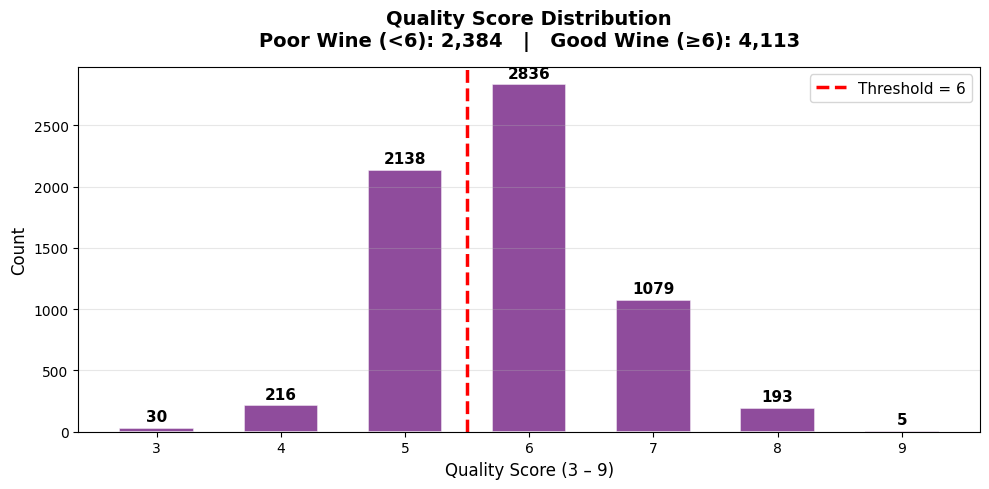

In [0]:
# ═════════════════════════════════════════════════════════════════════════════
# CHART 1 — Quality Score Distribution
# ═════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
q = df_eda["quality"].value_counts().sort_index()
bars = ax.bar(q.index, q.values, color="#7B2D8B", alpha=0.85,
              edgecolor="white", linewidth=1.2, width=0.6)

# Label each bar
for bar, val in zip(bars, q.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30, str(val),
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.axvline(x=BINARY_THRESHOLD - 0.5, color="red",
           linestyle="--", lw=2.5, label=f"Threshold = {BINARY_THRESHOLD}")
ax.set_title(
    f"Quality Score Distribution\n"
    f"Poor Wine (<{BINARY_THRESHOLD}): {poor_n:,}   |   "
    f"Good Wine (≥{BINARY_THRESHOLD}): {good_n:,}",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Quality Score (3 – 9)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.set_xticks(q.index)
plt.tight_layout()
plt.savefig("/tmp/eda_chart1_quality_dist.png", dpi=150, bbox_inches="tight")
plt.show()

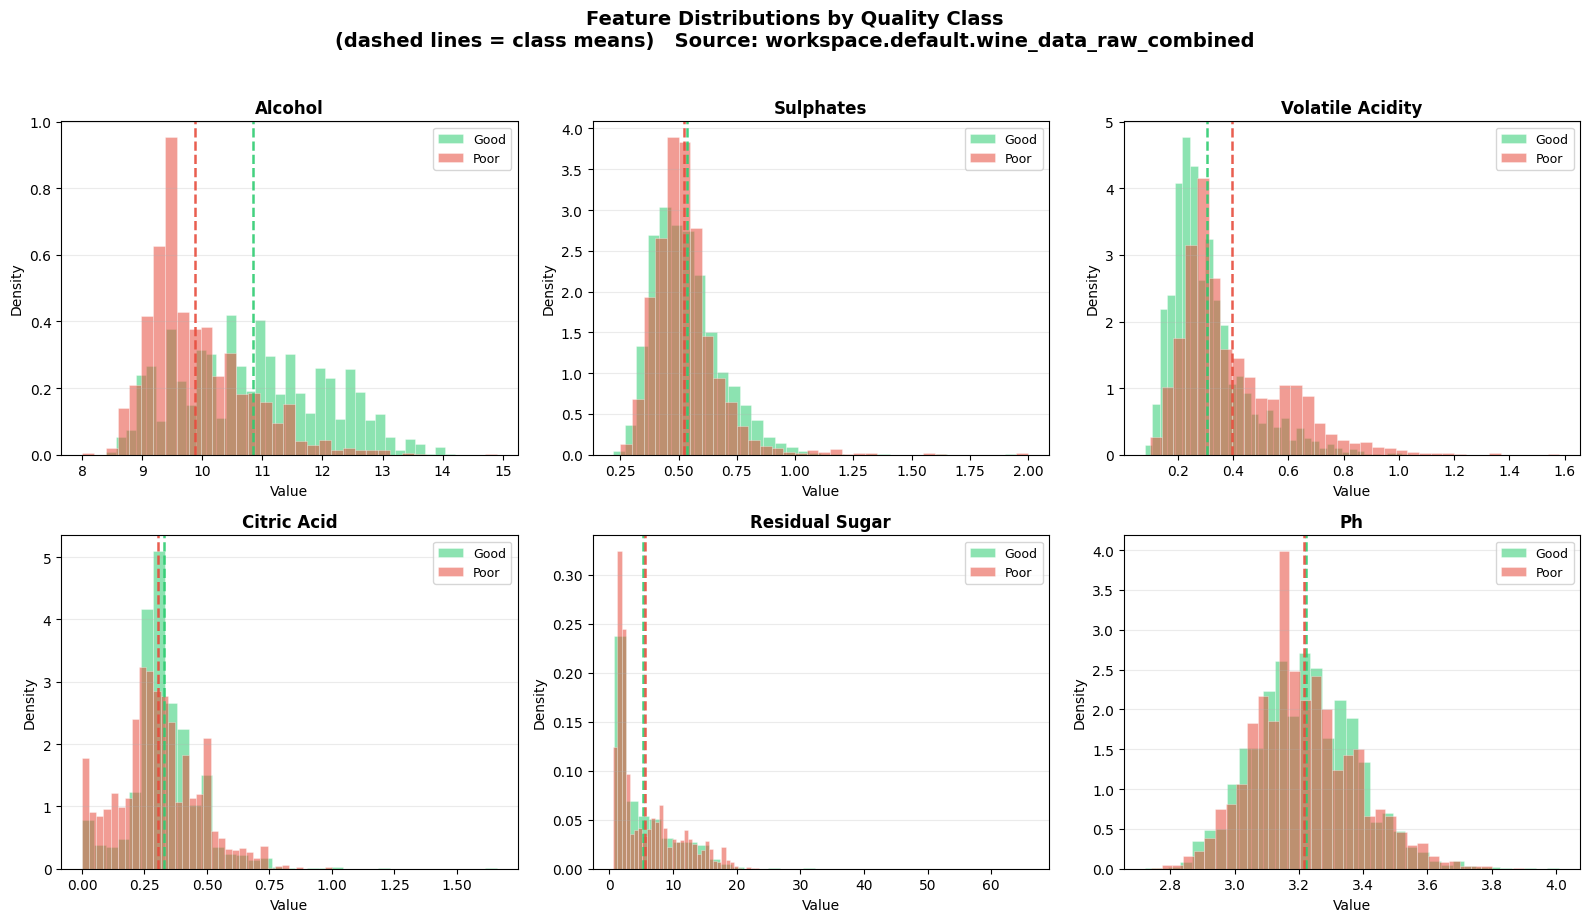

In [0]:
# ═════════════════════════════════════════════════════════════════════════════
# CHART 2 — Key Feature Distributions by Quality Class (2×3 grid)
# ═════════════════════════════════════════════════════════════════════════════
key_features = ["alcohol", "sulphates", "volatile_acidity",
                "citric_acid", "residual_sugar", "ph"]
colors       = {"Good": "#2ECC71", "Poor": "#E74C3C"}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feat in zip(axes, key_features):
    for cls, color in colors.items():
        prefix = f"Good (≥{BINARY_THRESHOLD})" if cls == "Good" else f"Poor (<{BINARY_THRESHOLD})"
        data   = df_eda[df_eda["class"] == prefix][feat].dropna()
        ax.hist(data, bins=35, alpha=0.55, color=color,
                label=cls, density=True, edgecolor="white", linewidth=0.4)
        # Vertical mean line
        ax.axvline(data.mean(), color=color, linestyle="--", lw=1.8, alpha=0.9)

    ax.set_title(feat.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_xlabel("Value", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.25)

plt.suptitle(
    "Feature Distributions by Quality Class\n"
    f"(dashed lines = class means)   Source: {UC_TABLE_RAW}",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("/tmp/eda_chart2_feature_dists.png", dpi=150, bbox_inches="tight")
plt.show()

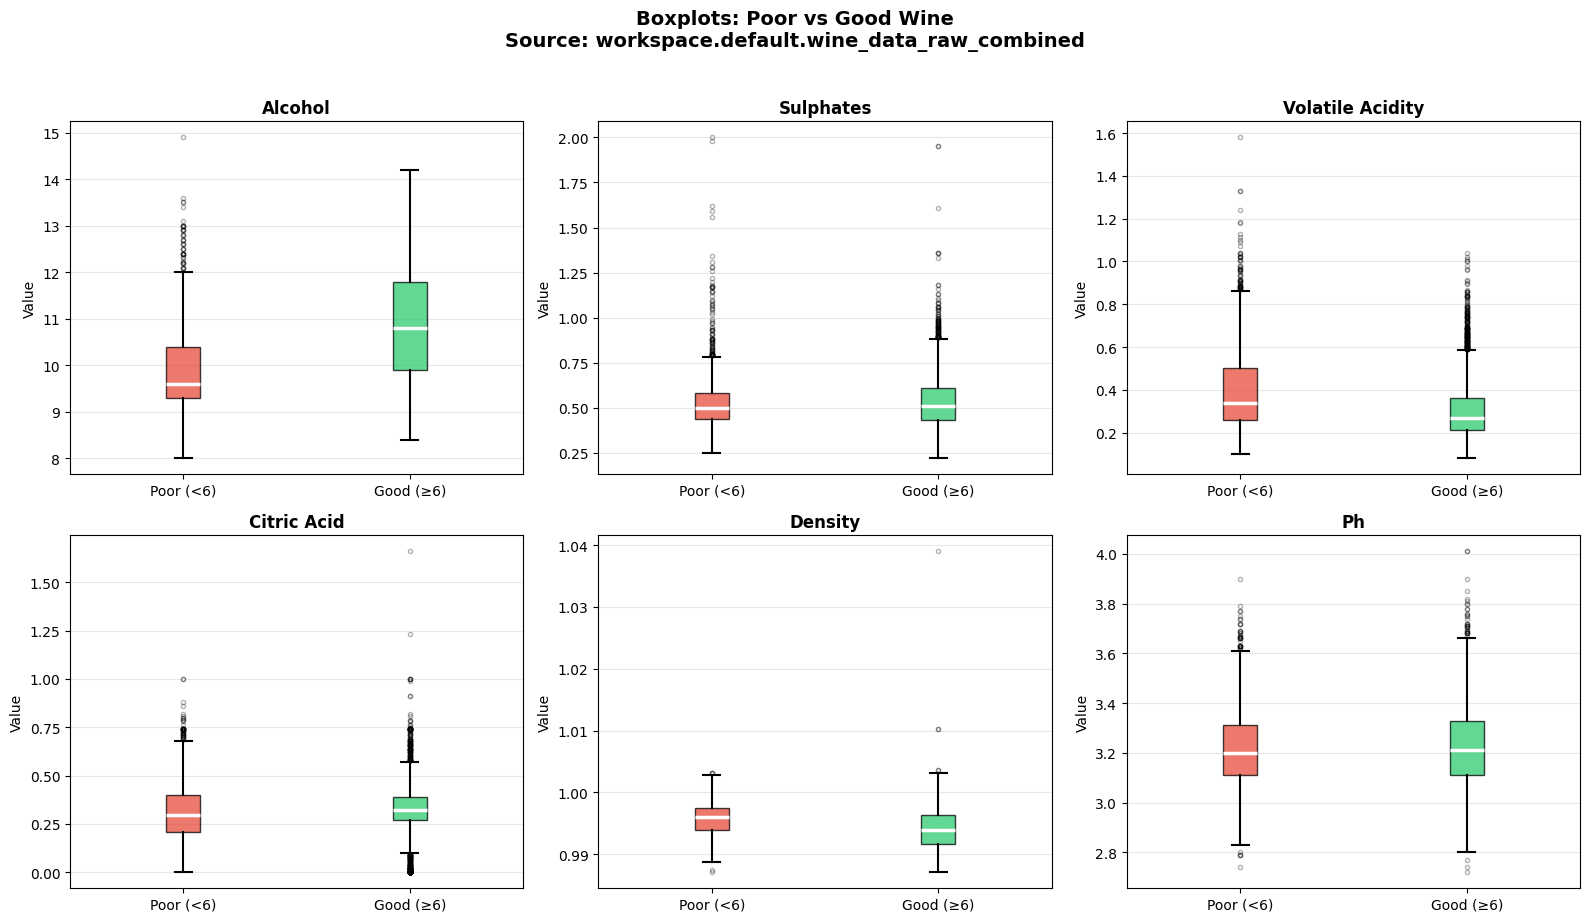

In [0]:
# ═════════════════════════════════════════════════════════════════════════════
# CHART 3 — Boxplots: Top features by quality class side-by-side
# ═════════════════════════════════════════════════════════════════════════════
box_features = ["alcohol", "sulphates", "volatile_acidity",
                "citric_acid", "density", "ph"]
palette      = {f"Poor (<{BINARY_THRESHOLD})": "#E74C3C",
                f"Good (≥{BINARY_THRESHOLD})": "#2ECC71"}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feat in zip(axes, box_features):
    data_poor = df_eda[df_eda["class"] == f"Poor (<{BINARY_THRESHOLD})"][feat].dropna()
    data_good = df_eda[df_eda["class"] == f"Good (≥{BINARY_THRESHOLD})"][feat].dropna()

    bp = ax.boxplot(
        [data_poor, data_good],
        labels=[f"Poor (<{BINARY_THRESHOLD})", f"Good (≥{BINARY_THRESHOLD})"],
        patch_artist=True,
        medianprops=dict(color="white", linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker="o", markersize=3, alpha=0.3)
    )
    bp["boxes"][0].set_facecolor("#E74C3C")
    bp["boxes"][0].set_alpha(0.75)
    bp["boxes"][1].set_facecolor("#2ECC71")
    bp["boxes"][1].set_alpha(0.75)

    ax.set_title(feat.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_ylabel("Value", fontsize=10)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Boxplots: Poor vs Good Wine\n"
    f"Source: {UC_TABLE_RAW}",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("/tmp/eda_chart3_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

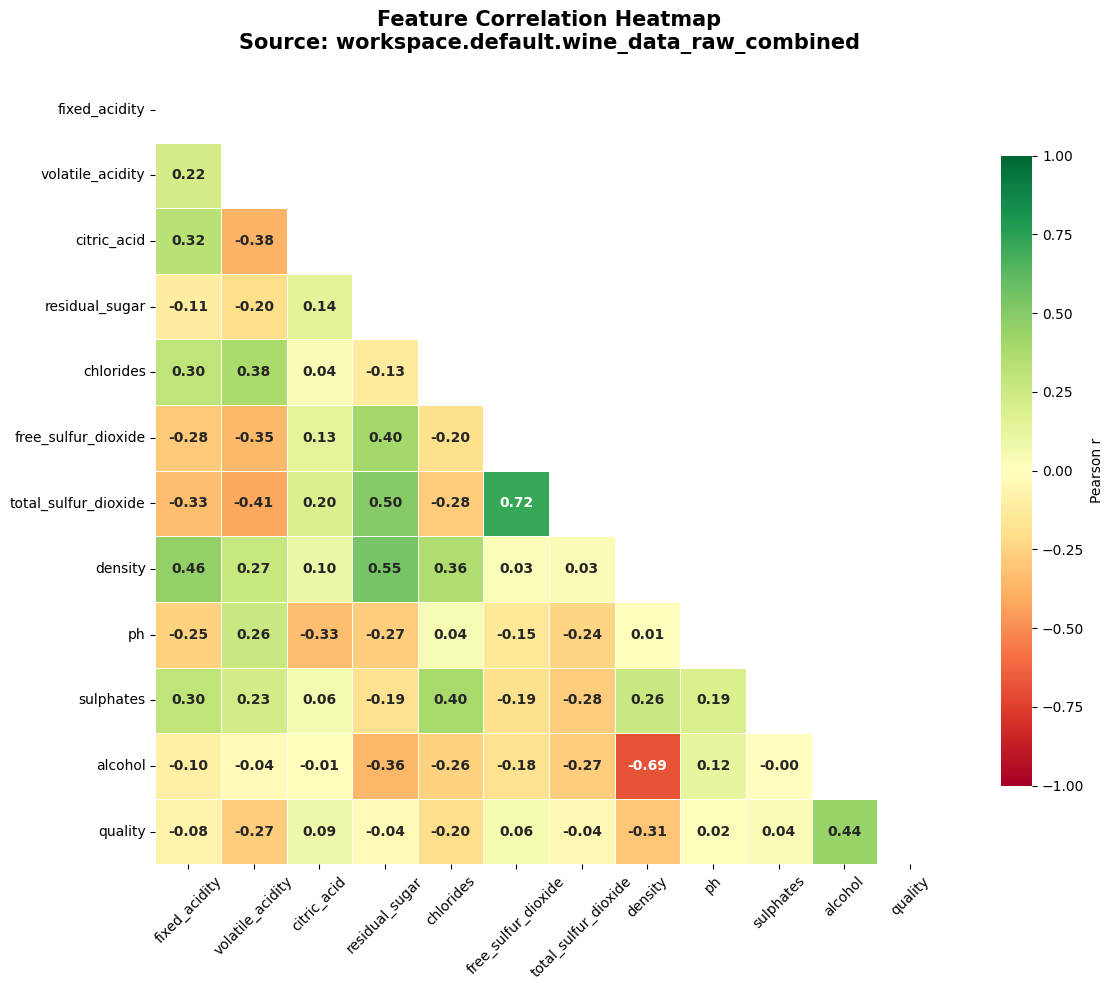

In [0]:
# ═════════════════════════════════════════════════════════════════════════════
# CHART 4 — Full Correlation Heatmap (standalone, large)
# ═════════════════════════════════════════════════════════════════════════════
num  = df_eda.select_dtypes(include=["number"]).drop(columns=["class"], errors="ignore")
corr = num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.6,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 10, "weight": "bold"},
    square=True,
    vmin=-1, vmax=1,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)
ax.set_title(
    f"Feature Correlation Heatmap\nSource: {UC_TABLE_RAW}",
    fontsize=15, fontweight="bold", pad=20
)
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", rotation=0,  labelsize=10)
plt.tight_layout()
plt.savefig("/tmp/eda_chart4_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


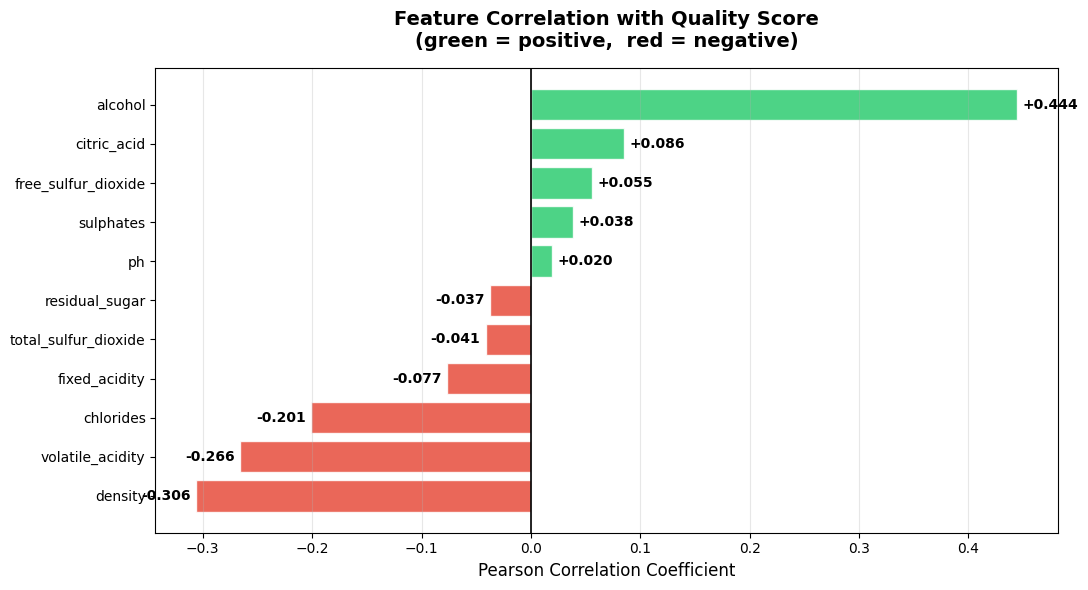

In [0]:
# ═════════════════════════════════════════════════════════════════════════════
# CHART 5 — Quality correlation bar chart (quality vs every feature)
# ═════════════════════════════════════════════════════════════════════════════
quality_corr = (num.corr()["quality"]
                   .drop("quality")
                   .sort_values())

colors_bar = ["#E74C3C" if v < 0 else "#2ECC71" for v in quality_corr.values]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(quality_corr.index, quality_corr.values,
               color=colors_bar, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, quality_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}",
            va="center", ha="left" if val >= 0 else "right",
            fontsize=10, fontweight="bold")
ax.axvline(0, color="black", lw=1.2)
ax.set_title("Feature Correlation with Quality Score\n"
             "(green = positive,  red = negative)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Pearson Correlation Coefficient", fontsize=12)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("/tmp/eda_chart5_quality_corr.png", dpi=150, bbox_inches="tight")
plt.show()

In [0]:
# Cleanup temp column
df_eda.drop(columns=["class"], inplace=True, errors="ignore")
print("\n✅  EDA complete — 5 charts rendered.")


✅  EDA complete — 5 charts rendered.


## Feature Engineering → Unity Catalog Features Table

| Quality | Binary Label |
|:---:|:---:|
| < 6 | `0` — Poor Wine |
| ≥ 6 | `1` — Good Wine |

**Engineered features added:**
- `so2_ratio` — free / total SO₂ (freshness proxy)
- `acidity_ratio` — fixed / volatile acidity (balance proxy)
- `alcohol_density` — alcohol / density (body proxy)
- `sugar_alcohol_ratio` — residual sugar / alcohol (sweetness proxy)
- `wine_type_enc` — 1=red, 0=white

In [0]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    data["target"]             = (data["quality"] >= BINARY_THRESHOLD).astype(int)
    data["so2_ratio"]          = data["free_sulfur_dioxide"] / (data["total_sulfur_dioxide"] + 1e-6)
    data["acidity_ratio"]      = data["fixed_acidity"]       / (data["volatile_acidity"]     + 1e-6)
    data["alcohol_density"]    = data["alcohol"]             / (data["density"]              + 1e-6)
    data["sugar_alcohol_ratio"]= data["residual_sugar"]      / (data["alcohol"]              + 1e-6)
    data["wine_type_enc"]      = (data["wine_type"] == "red").astype(int)
    data.drop(columns=["quality", "wine_type"], inplace=True)
    return data.dropna()

df_raw_uc = spark.table(UC_TABLE_RAW).toPandas()
df_feat   = build_features(df_raw_uc)

FEATURES = [c for c in df_feat.columns if c != "target"]
TARGET   = "target"

vc = df_feat[TARGET].value_counts()
print(f"Feature table shape : {df_feat.shape}")
print(f"Features ({len(FEATURES)})       : {FEATURES}")
print(f"\nTarget split:")
print(f"  Poor Wine (0) : {vc[0]:,}  ({vc[0]/len(df_feat)*100:.1f}%)")
print(f"  Good Wine (1) : {vc[1]:,}  ({vc[1]/len(df_feat)*100:.1f}%)")

# Write features to Unity Catalog
spark_feat = spark.createDataFrame(df_feat)
(spark_feat.write.format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(UC_TABLE_FEATURES))

# Tag the table
spark.sql(f"""ALTER TABLE {UC_TABLE_FEATURES} SET TBLPROPERTIES (
    'binary_threshold'    = '{BINARY_THRESHOLD}',
    'engineered_features' = 'so2_ratio,acidity_ratio,alcohol_density,sugar_alcohol_ratio,wine_type_enc',
    'source_table'        = '{UC_TABLE_RAW}',
    'purpose'             = 'binary_classification'
)""")

print(f"\n✅  Features written → {UC_TABLE_FEATURES}  ({spark.table(UC_TABLE_FEATURES).count():,} rows)")
_df_1 = spark.sql(f"DESCRIBE TABLE {UC_TABLE_FEATURES}").toPandas()
print(_df_1.to_string(index=True))

Feature table shape : (6497, 17)
Features (16)       : ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'ph', 'sulphates', 'alcohol', 'so2_ratio', 'acidity_ratio', 'alcohol_density', 'sugar_alcohol_ratio', 'wine_type_enc']

Target split:
  Poor Wine (0) : 2,384  (36.7%)
  Good Wine (1) : 4,113  (63.3%)

✅  Features written → workspace.default.wine_data_features  (6,497 rows)
                col_name data_type comment
0          fixed_acidity    double    None
1       volatile_acidity    double    None
2            citric_acid    double    None
3         residual_sugar    double    None
4              chlorides    double    None
5    free_sulfur_dioxide    double    None
6   total_sulfur_dioxide    double    None
7                density    double    None
8                     ph    double    None
9              sulphates    double    None
10               alcohol    double    None
11           

## Read Features from Unity Catalog → Train/Test Split + SMOTE

In [0]:
# Always read from Unity Catalog
df_model = spark.table(UC_TABLE_FEATURES).toPandas()
print(f"✅  Loaded from Unity Catalog: {UC_TABLE_FEATURES}  ({df_model.shape})")

X = df_model[FEATURES].values
y = df_model[TARGET].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=RANDOM_STATE, stratify=y
)

# Scale (needed for NB and LR)
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# SMOTE on training only
if SMOTE_ENABLED:
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train_sm_sc, y_train_sm = sm.fit_resample(X_train_scaled, y_train)
    X_train_sm_rw, _          = sm.fit_resample(X_train_raw,    y_train)
else:
    X_train_sm_sc, y_train_sm = X_train_scaled, y_train
    X_train_sm_rw             = X_train_raw

SPW = round((y_train == 0).sum() / (y_train == 1).sum(), 4)  # XGBoost scale_pos_weight

print(f"Train original  : {X_train_raw.shape[0]:,}")
print(f"Train SMOTE     : {X_train_sm_sc.shape[0]:,}")
print(f"Test            : {X_test_raw.shape[0]:,}")
print(f"scale_pos_weight: {SPW}  (XGBoost)")

# Cross-val splitter (shared by Optuna)
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

✅  Loaded from Unity Catalog: workspace.default.wine_data_features  ((6497, 17))
Train original  : 5,197
Train SMOTE     : 6,580
Test            : 1,300
scale_pos_weight: 0.5796  (XGBoost)


In [0]:
## Metric & Artifact Helper Functions
def compute_metrics(y_true, y_pred, y_prob) -> dict:
    cm = confusion_matrix(y_true, y_pred)
    tn, fp = cm[0,0], cm[0,1]
    return {
        "accuracy"    : round(accuracy_score(y_true, y_pred), 4),
        "precision"   : round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall"      : round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1_score"    : round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc"     : round(roc_auc_score(y_true, y_prob), 4),
        "specificity" : round(tn / (tn + fp + 1e-9), 4),
    }

In [0]:
def log_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Poor(0)","Good(1)"],
                yticklabels=["Poor(0)","Good(1)"],
                annot_kws={"size":14,"weight":"bold"})
    ax.set_title(f"Confusion Matrix\n{model_name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as d:
        p = os.path.join(d, f"cm_{model_name.replace(' ','_')}.png")
        fig.savefig(p, dpi=130); mlflow.log_artifact(p)
    plt.close(fig)

In [0]:
def log_roc_curve(y_true, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, lw=2.5, color="#7B2D8B", label=f"AUC={auc:.4f}")
    ax.plot([0,1],[0,1],"k--",lw=1.2,alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.12, color="#7B2D8B")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC Curve\n{model_name}", fontsize=12, fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as d:
        p = os.path.join(d, f"roc_{model_name.replace(' ','_')}.png")
        fig.savefig(p, dpi=130); mlflow.log_artifact(p)
    plt.close(fig)

In [0]:
def log_pr_curve(y_true, y_prob, model_name):
    pr, rc, _ = precision_recall_curve(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(rc, pr, lw=2.5, color="#E67E22")
    ax.fill_between(rc, pr, alpha=0.12, color="#E67E22")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"PR Curve\n{model_name}", fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3); plt.tight_layout()
    with tempfile.TemporaryDirectory() as d:
        p = os.path.join(d, f"pr_{model_name.replace(' ','_')}.png")
        fig.savefig(p, dpi=130); mlflow.log_artifact(p)
    plt.close(fig)

In [0]:
def log_feature_importance(model, feature_names, model_name):
    if not hasattr(model, "feature_importances_"): return
    imp  = model.feature_importances_
    idx  = np.argsort(imp)[::-1]
    topn = min(20, len(idx))
    fig, ax = plt.subplots(figsize=(10, 5))
    colors_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.9, topn))
    ax.bar(range(topn), imp[idx[:topn]], color=colors_fi, edgecolor="white")
    ax.set_xticks(range(topn))
    ax.set_xticklabels([feature_names[i] for i in idx[:topn]], rotation=40, ha="right", fontsize=9)
    ax.set_title(f"Feature Importance\n{model_name}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Importance"); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as d:
        p = os.path.join(d, f"fi_{model_name.replace(' ','_')}.png")
        fig.savefig(p, dpi=130); mlflow.log_artifact(p)
    plt.close(fig)

In [0]:
def log_cls_report(y_true, y_pred, model_name):
    rpt = classification_report(y_true, y_pred, target_names=["Poor(0)","Good(1)"])
    with tempfile.TemporaryDirectory() as d:
        p = os.path.join(d, f"report_{model_name.replace(' ','_')}.txt")
        with open(p,"w") as f:
            f.write(f"Model   : {model_name}\n")
            f.write(f"Source  : {UC_TABLE_FEATURES}\n")
            f.write("="*55+"\n\n"+rpt)
        mlflow.log_artifact(p)

In [0]:
def _build_signature(model, X_sample, feature_names):
    """
    Build an MLflow signature with NAMED columns so the UC model registry
    shows proper feature names (not auto-generated 1.0, 1.1, 1.2 etc).

    Always reconstructs a named pandas DataFrame from the raw numpy array
    so infer_signature sees string column names, not positional indices.
    """
    # Always use a named DataFrame — never pass raw numpy to infer_signature
    sample_df      = pd.DataFrame(X_sample[:5], columns=feature_names)
    sample_out     = model.predict(sample_df)          # predict from DataFrame
    signature      = infer_signature(sample_df, sample_out)
    return signature, sample_df

In [0]:
def _register_model(model, X_sample, flavor, reg_name, feature_names=None):
    """
    Log + register a model with signature and input_example.
    Passes explicit feature_names so column headers are correct in UC.
    Works with MLflow 2.x and 3.x (uses artifact_path for compat).
    """
    _feat = feature_names if feature_names is not None else FEATURES
    signature, input_example = _build_signature(model, X_sample, _feat)

    log_kwargs = dict(
        artifact_path   = "model",              # works across all MLflow versions
        registered_model_name = reg_name,
        signature       = signature,
        input_example   = input_example,
    )

    if flavor == "xgboost":
        mlflow.xgboost.log_model(model, **log_kwargs)
    else:
        mlflow.sklearn.log_model(model, **log_kwargs)

In [0]:
def train_log_model(model, model_name, X_tr, X_te, y_tr, y_te,
                    params, flavor="sklearn", parent_run_id=None):
    """
    Train one model, log all metrics + artifacts, register in Unity Catalog.
    Signature + input_example are ALWAYS included to satisfy UC requirements.
    """
    with mlflow.start_run(run_name=model_name, nested=True) as run:
        mlflow.set_tags({
            "model_type"       : model_name,
            "uc_feature_table" : UC_TABLE_FEATURES,
            "parent_run_id"    : parent_run_id or "",
        })
        mlflow.log_params(params)

        # ── Train ─────────────────────────────────────────────────────────────
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

        # ── Metrics ───────────────────────────────────────────────────────────
        m = compute_metrics(y_te, y_pred, y_prob)
        mlflow.log_metrics(m)

        # ── Artifact plots ────────────────────────────────────────────────────
        log_confusion_matrix(y_te, y_pred, model_name)
        log_roc_curve(y_te, y_prob, model_name)
        log_pr_curve(y_te, y_prob, model_name)
        log_feature_importance(model, FEATURES, model_name)
        log_cls_report(y_te, y_pred, model_name)

        # ── Register in Unity Catalog with signature ───────────────────────────
        reg_name = f"{UC_CATALOG}.{UC_SCHEMA}.{model_name.replace(' ', '_')}"
        _register_model(model, X_te, flavor, reg_name)

        return {"Model": model_name, "Run ID": run.info.run_id, **m}


print("✅  All helper functions defined.")
print("    _build_signature()  — infers input+output schema for UC")
print("    _register_model()   — logs model with signature + input_example")
print("    train_log_model()   — full train → log → register pipeline")

✅  All helper functions defined.
    _build_signature()  — infers input+output schema for UC
    _register_model()   — logs model with signature + input_example
    train_log_model()   — full train → log → register pipeline


## MLflow Baseline: All 4 Models (Parent + 4 Child Runs)

Each child run logs automatically:
- **Parameters** — hyperparameters used
- **Metrics** — Accuracy, Precision, Recall, F1, AUC-ROC, Specificity
- **Artifacts** — Confusion Matrix PNG, ROC Curve PNG, PR Curve PNG, Feature Importance PNG, Classification Report TXT
- **Model** — registered in Unity Catalog Model Registry

In [0]:
mlflow.set_experiment(EXPERIMENT_NAME)
baseline_results = []

with mlflow.start_run(run_name="Wine_Quality_Baseline") as parent:
    mlflow.set_tags({
        "run_type"        : "baseline_comparison",
        "uc_feature_table": UC_TABLE_FEATURES,
        "models"          : "NaiveBayes,LogisticRegression,RandomForest,XGBoost",
    })
    mlflow.log_params({
        "uc_catalog": UC_CATALOG, "uc_schema": UC_SCHEMA,
        "n_features": len(FEATURES), "binary_threshold": BINARY_THRESHOLD,
        "train_size": int(X_train_sm_sc.shape[0]), "test_size": int(X_test_raw.shape[0]),
        "smote_enabled": SMOTE_ENABLED,
    })

    print(f"🍷  Baseline Run ID : {parent.info.run_id}")
    print("=" * 72)

    # ── 1. Naive Bayes ────────────────────────────────────────────────────────
    print("\n  [1/4] Naive Bayes ...")
    r = train_log_model(
        GaussianNB(var_smoothing=1e-9),
        "Naive_Bayes", X_train_sm_sc, X_test_scaled, y_train_sm, y_test,
        {"var_smoothing": 1e-9, "scaling": "StandardScaler", "imbalance": "SMOTE"},
        parent_run_id=parent.info.run_id
    )
    baseline_results.append(r)
    print(f"      acc={r['accuracy']}  f1={r['f1_score']}  auc={r['roc_auc']}")

    # ── 2. Logistic Regression ────────────────────────────────────────────────
    print("\n  [2/4] Logistic Regression ...")
    r = train_log_model(
        LogisticRegression(C=0.5, solver="saga", penalty="l2",
                           max_iter=1000, class_weight="balanced",
                           random_state=RANDOM_STATE),
        "Logistic_Regression", X_train_sm_sc, X_test_scaled, y_train_sm, y_test,
        {"C": 0.5, "solver": "saga", "penalty": "l2", "max_iter": 1000,
         "class_weight": "balanced", "scaling": "StandardScaler", "imbalance": "SMOTE"},
        parent_run_id=parent.info.run_id
    )
    baseline_results.append(r)
    print(f"      acc={r['accuracy']}  f1={r['f1_score']}  auc={r['roc_auc']}")

    # ── 3. Random Forest (default params) ─────────────────────────────────────
    print("\n  [3/4] Random Forest (baseline) ...")
    r = train_log_model(
        RandomForestClassifier(n_estimators=200, max_depth=10,
                               class_weight="balanced",
                               random_state=RANDOM_STATE, n_jobs=-1),
        "Random_Forest_Baseline", X_train_sm_rw, X_test_raw, y_train_sm, y_test,
        {"n_estimators": 200, "max_depth": 10, "class_weight": "balanced",
         "imbalance": "SMOTE+balanced"},
        parent_run_id=parent.info.run_id
    )
    baseline_results.append(r)
    print(f"      acc={r['accuracy']}  f1={r['f1_score']}  auc={r['roc_auc']}")

    # ── 4. XGBoost (default params) ───────────────────────────────────────────
    print("\n  [4/4] XGBoost (baseline) ...")
    r = train_log_model(
        XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                      scale_pos_weight=SPW, eval_metric="logloss",
                      use_label_encoder=False,
                      random_state=RANDOM_STATE, n_jobs=-1),
        "XGBoost_Baseline", X_train_sm_rw, X_test_raw, y_train_sm, y_test,
        {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1,
         "scale_pos_weight": SPW, "imbalance": "SMOTE+scale_pos_weight"},
        flavor="xgboost", parent_run_id=parent.info.run_id
    )
    baseline_results.append(r)
    print(f"      acc={r['accuracy']}  f1={r['f1_score']}  auc={r['roc_auc']}")

    # Summary
    baseline_df = pd.DataFrame(baseline_results).sort_values("roc_auc", ascending=False)
    with tempfile.TemporaryDirectory() as d:
        p = os.path.join(d, "baseline_summary.csv")
        baseline_df.to_csv(p, index=False); mlflow.log_artifact(p)
    mlflow.set_tag("best_baseline", baseline_df.iloc[0]["Model"])

print("\n" + "=" * 72)
print("  BASELINE RESULTS")
print("=" * 72)
print(f"  {'Model':<30} {'Accuracy':>9} {'F1':>8} {'AUC-ROC':>9}")
print("  " + "─" * 60)
for _, row in baseline_df.iterrows():
    print(f"  {row['Model']:<30} {row['accuracy']:>9.4f} {row['f1_score']:>8.4f} {row['roc_auc']:>9.4f}")

🍷  Baseline Run ID : 9b34545f2ad34da2afa307e79986cc85

  [1/4] Naive Bayes ...


2026/03/01 17:17:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-26ed6c6b-6092.cloud.databricks.com/ml/experiments/3890221684142316/models/m-25245599705741a4b029229104bf21ff?o=166342111796278
Registered model 'workspace.default.Naive_Bayes' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '4' of model 'workspace.default.naive_bayes': https://dbc-26ed6c6b-6092.cloud.databricks.com/explore/data/models/workspace/default/naive_bayes/version/4?o=166342111796278


      acc=0.6946  f1=0.7362  auc=0.7619

  [2/4] Logistic Regression ...


...

      acc=0.7723  f1=0.8119  auc=0.8587

  [4/4] XGBoost (baseline) ...


2026/03/01 17:18:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-26ed6c6b-6092.cloud.databricks.com/ml/experiments/3890221684142316/models/m-a598b4efc5064292987d0bdd0c9a28f4?o=166342111796278
Registered model 'workspace.default.XGBoost_Baseline' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '4' of model 'workspace.default.xgboost_baseline': https://dbc-26ed6c6b-6092.cloud.databricks.com/explore/data/models/workspace/default/xgboost_baseline/version/4?o=166342111796278


      acc=0.7677  f1=0.8005  auc=0.8511

  BASELINE RESULTS
  Model                           Accuracy       F1   AUC-ROC
  ────────────────────────────────────────────────────────────
  Random_Forest_Baseline            0.7723   0.8119    0.8587
  XGBoost_Baseline                  0.7677   0.8005    0.8511
  Logistic_Regression               0.7262   0.7703    0.7897
  Naive_Bayes                       0.6946   0.7362    0.7619


##Optuna Hyperparameter Tuning: Random Forest

**Each Optuna trial is logged as a nested child run** so you can compare all trials
in the MLflow UI and see exactly which hyperparameter combination scored highest.

**Search space:**
| Parameter | Range |
|:---|:---|
| `n_estimators` | 100 – 600 |
| `max_depth` | 4 – 20 |
| `min_samples_split` | 2 – 12 |
| `min_samples_leaf` | 1 – 8 |
| `max_features` | sqrt / log2 / 0.5 / 0.7 |
| `bootstrap` | True / False |

In [0]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment(EXPERIMENT_NAME)

best_rf_params  = None
best_rf_auc     = 0.0
best_rf_run_id  = None
rf_trial_results = []

In [0]:
# ── Kernel state guard: verify _build_signature is the 3-arg version ─────────
import inspect
_sig_params = list(inspect.signature(_build_signature).parameters.keys())
assert len(_sig_params) == 3, (
    f"Wrong _build_signature loaded — has params {_sig_params}. "
    "Re-run Cell 10 (helper functions) first, then re-run this cell."
)
print(f"_build_signature signature OK: {_sig_params}")
optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment(EXPERIMENT_NAME)

best_rf_params  = None
best_rf_auc     = 0.0
best_rf_run_id  = None
rf_trial_results = []

def rf_objective(trial, parent_run_id):
    """Optuna objective — each call is one nested MLflow child run."""
    global best_rf_params, best_rf_auc

    params = {
        "n_estimators"      : trial.suggest_int("n_estimators",       100, 600, step=50),
        "max_depth"         : trial.suggest_int("max_depth",           4,  20),
        "min_samples_split" : trial.suggest_int("min_samples_split",   2,  12),
        "min_samples_leaf"  : trial.suggest_int("min_samples_leaf",    1,  8),
        "max_features"      : trial.suggest_categorical("max_features", ["sqrt","log2",0.5,0.7]),
        "bootstrap"         : trial.suggest_categorical("bootstrap",    [True, False]),
        "class_weight"      : "balanced",
        "random_state"      : RANDOM_STATE,
        "n_jobs"            : -1,
    }

    model = RandomForestClassifier(**params)

    # 5-fold CV AUC on training data
    cv_auc = cross_val_score(model, X_train_sm_rw, y_train_sm,
                             cv=CV, scoring="roc_auc", n_jobs=-1).mean()

    # Log this trial as a child run
    with mlflow.start_run(run_name=f"RF_Trial_{trial.number}", nested=True) as child:
        mlflow.set_tags({"trial_number": trial.number, "model_type": "RandomForest",
                         "parent_run_id": parent_run_id, "tuning": "optuna"})
        mlflow.log_params(params)
        mlflow.log_metric("cv_roc_auc", round(cv_auc, 4))

        # Also evaluate on held-out test set
        model.fit(X_train_sm_rw, y_train_sm)
        y_pred = model.predict(X_test_raw)
        y_prob = model.predict_proba(X_test_raw)[:, 1]
        m = compute_metrics(y_test, y_pred, y_prob)
        mlflow.log_metrics(m)

        rf_trial_results.append({"trial": trial.number, "cv_auc": round(cv_auc,4), **m, **params})

        if cv_auc > best_rf_auc:
            best_rf_auc    = cv_auc
            best_rf_params = params

    return cv_auc

_build_signature signature OK: ['model', 'X_sample', 'feature_names']


In [0]:
with mlflow.start_run(run_name="RF_Optuna_Tuning") as rf_parent:
    mlflow.set_tags({
        "run_type"         : "hyperparameter_tuning",
        "model"            : "RandomForest",
        "tuning_framework" : "Optuna",
        "uc_feature_table" : UC_TABLE_FEATURES,
    })
    mlflow.log_params({
        "n_trials"         : OPTUNA_TRIALS_RF,
        "cv_folds"         : 5,
        "scoring"          : "roc_auc",
        "direction"        : "maximize",
        "sampler"          : "TPESampler",
    })

    print(f"🔬  Optuna RF Tuning — {OPTUNA_TRIALS_RF} trials")
    print(f"    Parent Run ID : {rf_parent.info.run_id}")
    print("    Progress: ", end="", flush=True)

    study_rf = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study_rf.optimize(
        lambda t: rf_objective(t, rf_parent.info.run_id),
        n_trials=OPTUNA_TRIALS_RF,
        callbacks=[lambda s, t: print("▓", end="", flush=True)]
    )
    print()

    # Train final best RF and log to parent
    best_rf_model = RandomForestClassifier(**best_rf_params)
    best_rf_model.fit(X_train_sm_rw, y_train_sm)
    y_pred_rf = best_rf_model.predict(X_test_raw)
    y_prob_rf = best_rf_model.predict_proba(X_test_raw)[:, 1]
    best_rf_metrics = compute_metrics(y_test, y_pred_rf, y_prob_rf)

    mlflow.log_params({f"best_{k}": v for k, v in best_rf_params.items()})
    mlflow.log_metrics({f"best_{k}": v for k, v in best_rf_metrics.items()})
    mlflow.log_metric("best_cv_roc_auc", round(study_rf.best_value, 4))

    # Log final best model as its own child run AND register in UC
    with mlflow.start_run(run_name="Best_RF_Optuna", nested=True) as best_rf_run:
        mlflow.log_params(best_rf_params)
        mlflow.log_metrics(best_rf_metrics)
        log_confusion_matrix(y_test, y_pred_rf, "Best RF (Optuna)")
        log_roc_curve(y_test, y_prob_rf, "Best RF (Optuna)")
        log_pr_curve(y_test, y_prob_rf, "Best RF (Optuna)")
        log_feature_importance(best_rf_model, FEATURES, "Best RF (Optuna)")
        log_cls_report(y_test, y_pred_rf, "Best RF (Optuna)")

        # ── Build signature then register Best RF in Unity Catalog ────────────
        rf_reg_name               = f"{UC_CATALOG}.{UC_SCHEMA}.Random_Forest_Optuna"
        # _build_signature(model, X_sample, feature_names) — 3 args, defined in Cell 10
        _rf_sig, _rf_example      = _build_signature(best_rf_model, X_test_raw[:5], FEATURES)
        mlflow.sklearn.log_model(
            best_rf_model,
            artifact_path         = "model",
            registered_model_name = rf_reg_name,
            signature             = _rf_sig,
            input_example         = _rf_example,
        )
        best_rf_run_id = best_rf_run.info.run_id

    mlflow.set_tag("best_trial",    str(study_rf.best_trial.number))
    mlflow.set_tag("best_cv_auc",   str(round(study_rf.best_value, 4)))
    mlflow.set_tag("registered_as", rf_reg_name)

🔬  Optuna RF Tuning — 30 trials
    Parent Run ID : 76631e1953ed48168d470929f8fb087e
    Progress: ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓


2026/03/01 17:35:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-26ed6c6b-6092.cloud.databricks.com/ml/experiments/3890221684142316/models/m-d03d2ff18728443280b8413744d2a52a?o=166342111796278
Registered model 'workspace.default.Random_Forest_Optuna' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '2' of model 'workspace.default.random_forest_optuna': https://dbc-26ed6c6b-6092.cloud.databricks.com/explore/data/models/workspace/default/random_forest_optuna/version/2?o=166342111796278




✅  RF Optuna complete!
    Best trial     : #18
    Best CV AUC    : 0.9285
    Test AUC       : 0.897
    Test F1        : 0.8486
    Best params    : {'n_estimators': 500, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False}
    Registered as  : workspace.default.Random_Forest_Optuna


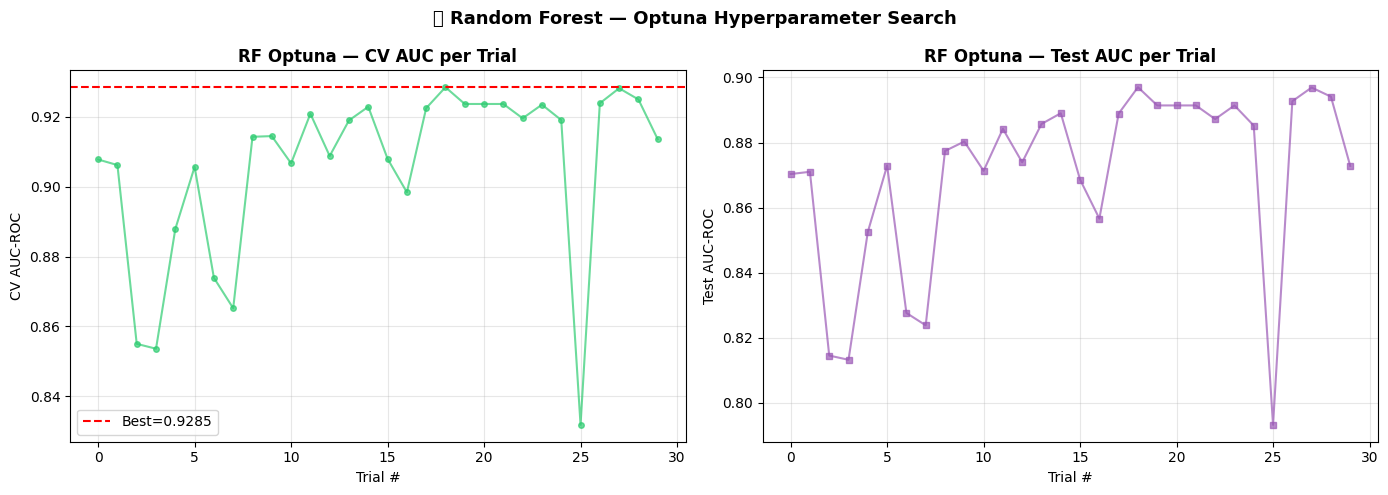

In [0]:
print(f"\n\n✅  RF Optuna complete!")
print(f"    Best trial     : #{study_rf.best_trial.number}")
print(f"    Best CV AUC    : {study_rf.best_value:.4f}")
print(f"    Test AUC       : {best_rf_metrics['roc_auc']}")
print(f"    Test F1        : {best_rf_metrics['f1_score']}")
print(f"    Best params    : {study_rf.best_params}")
print(f"    Registered as  : {rf_reg_name}")

# Visualise Optuna results
rf_trial_df = pd.DataFrame(rf_trial_results)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(rf_trial_df["trial"], rf_trial_df["cv_auc"], "o-",
             color="#2ECC71", lw=1.5, markersize=4, alpha=0.7)
axes[0].axhline(study_rf.best_value, color="red", linestyle="--",
                label=f"Best={study_rf.best_value:.4f}")
axes[0].set_title("RF Optuna — CV AUC per Trial", fontweight="bold")
axes[0].set_xlabel("Trial #"); axes[0].set_ylabel("CV AUC-ROC"); axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rf_trial_df["trial"], rf_trial_df["roc_auc"], "s-",
             color="#9B59B6", lw=1.5, markersize=4, alpha=0.7)
axes[1].set_title("RF Optuna — Test AUC per Trial", fontweight="bold")
axes[1].set_xlabel("Trial #"); axes[1].set_ylabel("Test AUC-ROC")
axes[1].grid(alpha=0.3)

plt.suptitle("🌲 Random Forest — Optuna Hyperparameter Search", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## Optuna Hyperparameter Tuning: XGBoost

**Search space:**
| Parameter | Range |
|:---|:---|
| `n_estimators` | 100 – 600 |
| `max_depth` | 3 – 10 |
| `learning_rate` | 0.01 – 0.3 (log scale) |
| `subsample` | 0.5 – 1.0 |
| `colsample_bytree` | 0.5 – 1.0 |
| `gamma` | 0 – 5 |
| `reg_alpha` | 1e-8 – 10 (log scale) |
| `reg_lambda` | 1e-8 – 10 (log scale) |
| `min_child_weight` | 1 – 10 |

🔬  Optuna XGBoost Tuning — 30 trials
    Parent Run ID : 0a704eed818f4597a675cb8e92073ef4
    Progress: 

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c1def78c-a01f-42f9-b3a0-a07fba318f0f/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:37:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-c1def78c-a01f-42f9-b3a0-a07fba318f0f/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:37:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-c1def78c-a01f-42f9-b3a0-a07fba318f0f/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:37:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-c1def78c-a01f-42f9-b3a0-a07fba318f0f/lib/pyth

▓

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c1def78c-a01f-42f9-b3a0-a07fba318f0f/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:37:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-c1def78c-a01f-42f9-b3a0-a07fba318f0f/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:37:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-c1def78c-a01f-42f9-b3a0-a07fba318f0f/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:37:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-c1def78c-a01f-42f9-b3a0-a07fba318f0f/lib/pyth

▓

...

▓


🔗 View Logged Model at: https://dbc-26ed6c6b-6092.cloud.databricks.com/ml/experiments/3890221684142316/models/m-d9b78e3087e04be1956612b90385e2ec?o=166342111796278
Registered model 'workspace.default.XGBoost_Optuna' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '2' of model 'workspace.default.xgboost_optuna': https://dbc-26ed6c6b-6092.cloud.databricks.com/explore/data/models/workspace/default/xgboost_optuna/version/2?o=166342111796278




✅  XGBoost Optuna complete!
    Best trial     : #26
    Best CV AUC    : 0.9103
    Test AUC       : 0.8753
    Test F1        : 0.8454
    Registered as  : workspace.default.XGBoost_Optuna


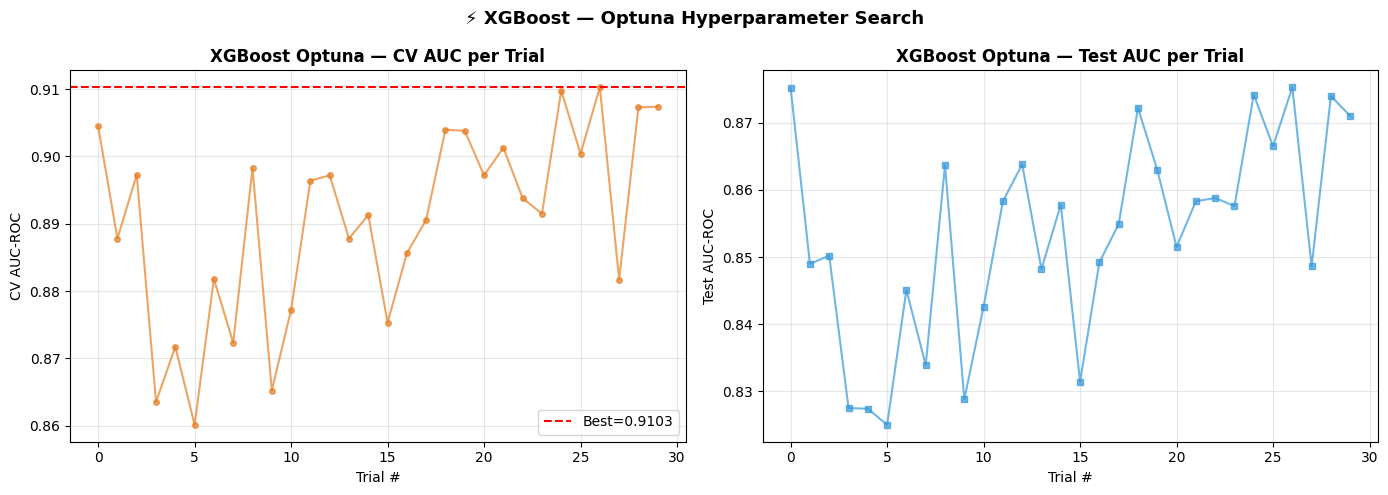

In [0]:
from sklearn.model_selection import cross_val_score

best_xgb_params  = None
best_xgb_auc     = 0.0
best_xgb_run_id  = None
xgb_trial_results = []

def xgb_objective(trial, parent_run_id):
    global best_xgb_params, best_xgb_auc

    params = {
        "n_estimators"     : trial.suggest_int("n_estimators",     100, 600, step=50),
        "max_depth"        : trial.suggest_int("max_depth",         3,  10),
        "learning_rate"    : trial.suggest_float("learning_rate",   0.01, 0.3, log=True),
        "subsample"        : trial.suggest_float("subsample",       0.5,  1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree",0.5,  1.0),
        "gamma"            : trial.suggest_float("gamma",           0.0,  5.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha",       1e-8, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda",      1e-8, 10.0, log=True),
        "min_child_weight" : trial.suggest_int("min_child_weight",  1,   10),
        "scale_pos_weight" : SPW,
        "eval_metric"      : "logloss",
        "use_label_encoder": False,
        "random_state"     : RANDOM_STATE,
        "n_jobs"           : -1,
    }

    model = XGBClassifier(**params)
    cv_auc = cross_val_score(model, X_train_sm_rw, y_train_sm,
                             cv=CV, scoring="roc_auc", n_jobs=-1).mean()

    with mlflow.start_run(run_name=f"XGB_Trial_{trial.number}", nested=True):
        mlflow.set_tags({"trial_number": trial.number, "model_type": "XGBoost",
                         "parent_run_id": parent_run_id, "tuning": "optuna"})
        log_params = {k: v for k, v in params.items()
                      if k not in ["eval_metric","use_label_encoder","random_state","n_jobs"]}
        mlflow.log_params(log_params)
        mlflow.log_metric("cv_roc_auc", round(cv_auc, 4))

        model.fit(X_train_sm_rw, y_train_sm)
        y_pred = model.predict(X_test_raw)
        y_prob = model.predict_proba(X_test_raw)[:, 1]
        m = compute_metrics(y_test, y_pred, y_prob)
        mlflow.log_metrics(m)
        xgb_trial_results.append({"trial": trial.number, "cv_auc": round(cv_auc,4), **m})

        if cv_auc > best_xgb_auc:
            best_xgb_auc    = cv_auc
            best_xgb_params = params

    return cv_auc

with mlflow.start_run(run_name="XGB_Optuna_Tuning") as xgb_parent:
    mlflow.set_tags({
        "run_type"         : "hyperparameter_tuning",
        "model"            : "XGBoost",
        "tuning_framework" : "Optuna",
        "uc_feature_table" : UC_TABLE_FEATURES,
    })
    mlflow.log_params({"n_trials": OPTUNA_TRIALS_XGB, "cv_folds": 5,
                       "scoring": "roc_auc", "direction": "maximize"})

    print(f"🔬  Optuna XGBoost Tuning — {OPTUNA_TRIALS_XGB} trials")
    print(f"    Parent Run ID : {xgb_parent.info.run_id}")
    print("    Progress: ", end="", flush=True)

    study_xgb = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study_xgb.optimize(
        lambda t: xgb_objective(t, xgb_parent.info.run_id),
        n_trials=OPTUNA_TRIALS_XGB,
        callbacks=[lambda s, t: print("▓", end="", flush=True)]
    )
    print()

    # Train and log best XGBoost
    best_xgb_model = XGBClassifier(**best_xgb_params)
    best_xgb_model.fit(X_train_sm_rw, y_train_sm)
    y_pred_xgb = best_xgb_model.predict(X_test_raw)
    y_prob_xgb = best_xgb_model.predict_proba(X_test_raw)[:, 1]
    best_xgb_metrics = compute_metrics(y_test, y_pred_xgb, y_prob_xgb)

    mlflow.log_metrics({f"best_{k}": v for k, v in best_xgb_metrics.items()})
    mlflow.log_metric("best_cv_roc_auc", round(study_xgb.best_value, 4))

    with mlflow.start_run(run_name="Best_XGBoost_Optuna", nested=True) as best_xgb_run:
        log_p = {k: v for k, v in best_xgb_params.items()
                 if k not in ["eval_metric","use_label_encoder","random_state","n_jobs"]}
        mlflow.log_params(log_p)
        mlflow.log_metrics(best_xgb_metrics)
        log_confusion_matrix(y_test, y_pred_xgb, "Best XGBoost (Optuna)")
        log_roc_curve(y_test, y_prob_xgb, "Best XGBoost (Optuna)")
        log_pr_curve(y_test, y_prob_xgb, "Best XGBoost (Optuna)")
        log_feature_importance(best_xgb_model, FEATURES, "Best XGBoost (Optuna)")
        log_cls_report(y_test, y_pred_xgb, "Best XGBoost (Optuna)")

        xgb_reg_name  = f"{UC_CATALOG}.{UC_SCHEMA}.XGBoost_Optuna"
        _in_xgb       = pd.DataFrame(X_test_raw[:5], columns=FEATURES)
        _sig_xgb      = infer_signature(_in_xgb, best_xgb_model.predict(X_test_raw[:5]))
        mlflow.xgboost.log_model(
            best_xgb_model,
            name="XGBoost_Optuna",
            registered_model_name=xgb_reg_name,
            signature=_sig_xgb,
            input_example=_in_xgb,
        )
        best_xgb_run_id = best_xgb_run.info.run_id

    mlflow.set_tag("best_trial",    str(study_xgb.best_trial.number))
    mlflow.set_tag("best_cv_auc",   str(round(study_xgb.best_value, 4)))
    mlflow.set_tag("registered_as", xgb_reg_name)

print(f"\n\n✅  XGBoost Optuna complete!")
print(f"    Best trial     : #{study_xgb.best_trial.number}")
print(f"    Best CV AUC    : {study_xgb.best_value:.4f}")
print(f"    Test AUC       : {best_xgb_metrics['roc_auc']}")
print(f"    Test F1        : {best_xgb_metrics['f1_score']}")
print(f"    Registered as  : {xgb_reg_name}")

xgb_trial_df = pd.DataFrame(xgb_trial_results)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(xgb_trial_df["trial"], xgb_trial_df["cv_auc"], "o-",
             color="#E67E22", lw=1.5, markersize=4, alpha=0.7)
axes[0].axhline(study_xgb.best_value, color="red", linestyle="--",
                label=f"Best={study_xgb.best_value:.4f}")
axes[0].set_title("XGBoost Optuna — CV AUC per Trial", fontweight="bold")
axes[0].set_xlabel("Trial #"); axes[0].set_ylabel("CV AUC-ROC"); axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(xgb_trial_df["trial"], xgb_trial_df["roc_auc"], "s-",
             color="#3498DB", lw=1.5, markersize=4, alpha=0.7)
axes[1].set_title("XGBoost Optuna — Test AUC per Trial", fontweight="bold")
axes[1].set_xlabel("Trial #"); axes[1].set_ylabel("Test AUC-ROC")
axes[1].grid(alpha=0.3)
plt.suptitle("⚡ XGBoost — Optuna Hyperparameter Search", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

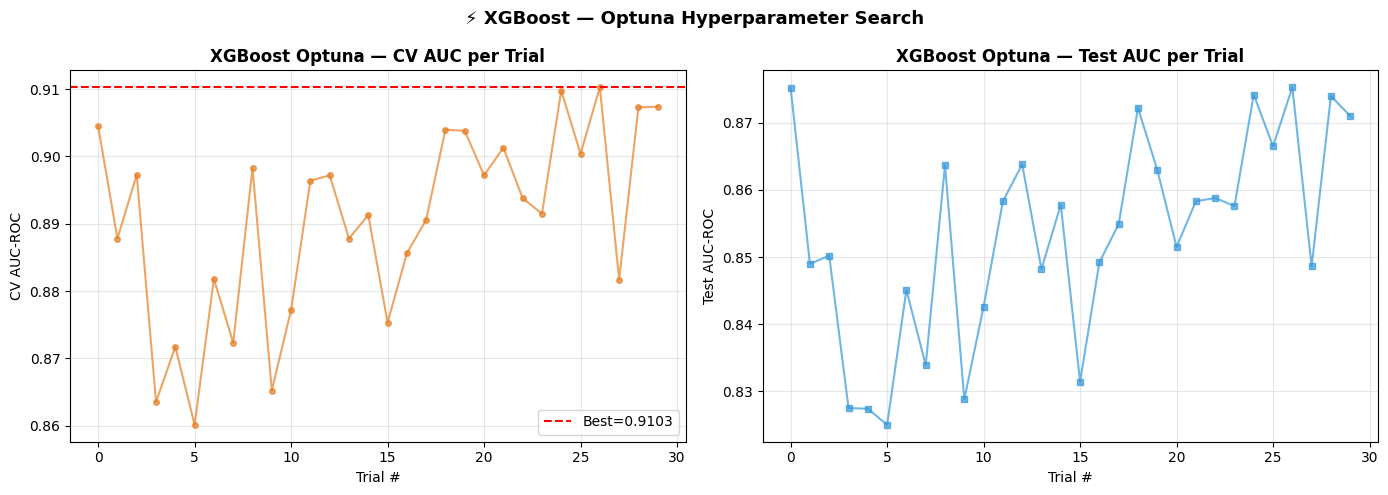

In [0]:
xgb_trial_df = pd.DataFrame(xgb_trial_results)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(xgb_trial_df["trial"], xgb_trial_df["cv_auc"], "o-",
             color="#E67E22", lw=1.5, markersize=4, alpha=0.7)
axes[0].axhline(study_xgb.best_value, color="red", linestyle="--",
                label=f"Best={study_xgb.best_value:.4f}")
axes[0].set_title("XGBoost Optuna — CV AUC per Trial", fontweight="bold")
axes[0].set_xlabel("Trial #"); axes[0].set_ylabel("CV AUC-ROC"); axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(xgb_trial_df["trial"], xgb_trial_df["roc_auc"], "s-",
             color="#3498DB", lw=1.5, markersize=4, alpha=0.7)
axes[1].set_title("XGBoost Optuna — Test AUC per Trial", fontweight="bold")
axes[1].set_xlabel("Trial #"); axes[1].set_ylabel("Test AUC-ROC")
axes[1].grid(alpha=0.3)
plt.suptitle("⚡ XGBoost — Optuna Hyperparameter Search", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## Full Model Leaderboard (Baseline + Optuna Tuned)

In [0]:
all_results = baseline_results.copy()
all_results.append({"Model": "RF_Optuna",  "run_id": best_rf_run_id,  **best_rf_metrics})
all_results.append({"Model": "XGB_Optuna", "run_id": best_xgb_run_id, **best_xgb_metrics})

leaderboard = (pd.DataFrame(all_results)
               .sort_values("roc_auc", ascending=False)
               .reset_index(drop=True))

print("=" * 80)
print("  FULL LEADERBOARD — Baseline + Optuna Tuned")
print(f"  Source: {UC_TABLE_FEATURES}")
print("=" * 80)
print(f"  {'#':<3} {'Model':<30} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>8} {'Spec':>7}")
print("  " + "─" * 64)
for rank, (_, row) in enumerate(leaderboard.iterrows(), 1):
    star = "  ⭐ BEST" if rank == 1 else ("  🔬 Optuna" if "Optuna" in row["Model"] else "")
    print(f"  {rank:<3} {row['Model']:<30} "
          f"{row['accuracy']:>7.4f} {row['precision']:>7.4f} "
          f"{row['recall']:>7.4f} {row['f1_score']:>7.4f} "
          f"{row['roc_auc']:>8.4f} {row['specificity']:>7.4f}{star}")

display(leaderboard[["Model","accuracy","precision","recall","f1_score","roc_auc","specificity"]])

  FULL LEADERBOARD — Baseline + Optuna Tuned
  Source: workspace.default.wine_data_features
  #   Model                              Acc    Prec     Rec      F1      AUC    Spec
  ────────────────────────────────────────────────────────────────
  1   RF_Optuna                       0.8123  0.8669  0.8311  0.8486   0.8970  0.7799  ⭐ BEST
  2   XGB_Optuna                      0.8115  0.8793  0.8141  0.8454   0.8753  0.8071  🔬 Optuna
  3   Random_Forest_Baseline          0.7723  0.8509  0.7764  0.8119   0.8587  0.7652
  4   XGBoost_Baseline                0.7677  0.8770  0.7363  0.8005   0.8511  0.8218
  5   Logistic_Regression             0.7262  0.8212  0.7254  0.7703   0.7897  0.7275
  6   Naive_Bayes                     0.6946  0.8123  0.6731  0.7362   0.7619  0.7317


Model,accuracy,precision,recall,f1_score,roc_auc,specificity
RF_Optuna,0.8123,0.8669,0.8311,0.8486,0.897,0.7799
XGB_Optuna,0.8115,0.8793,0.8141,0.8454,0.8753,0.8071
Random_Forest_Baseline,0.7723,0.8509,0.7764,0.8119,0.8587,0.7652
XGBoost_Baseline,0.7677,0.877,0.7363,0.8005,0.8511,0.8218
Logistic_Regression,0.7262,0.8212,0.7254,0.7703,0.7897,0.7275
Naive_Bayes,0.6946,0.8123,0.6731,0.7362,0.7619,0.7317


## Visual Model Comparison

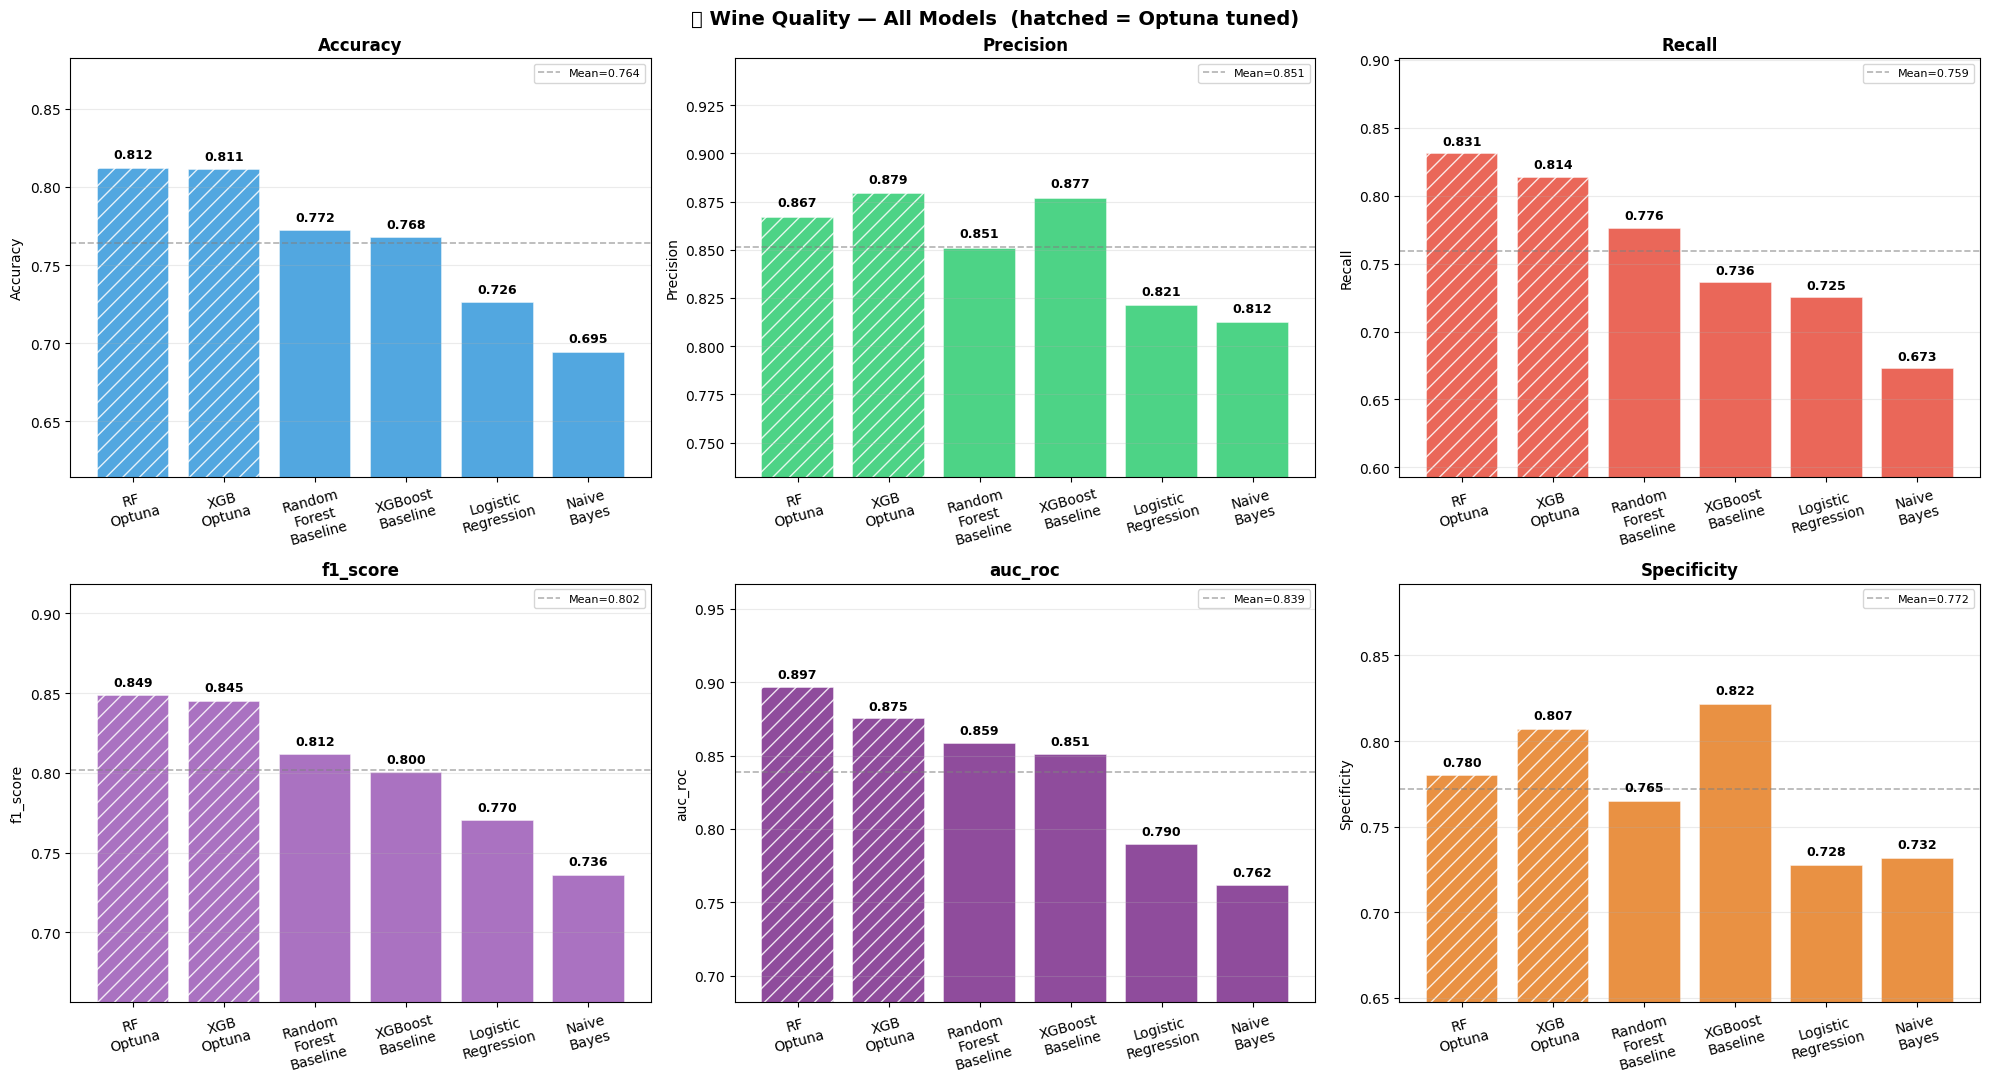

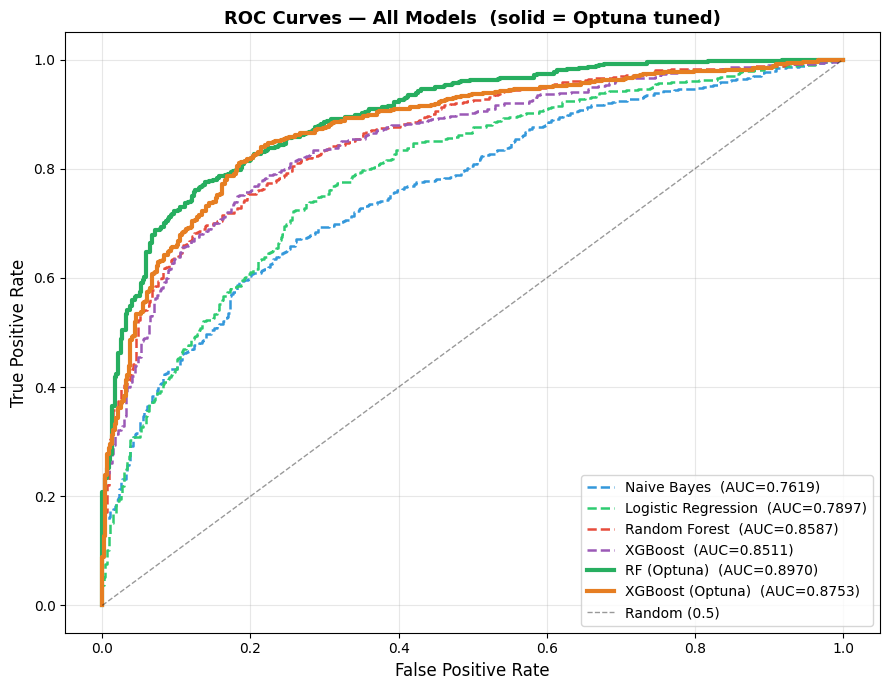

In [0]:
metrics_meta = [
    ("accuracy","Accuracy","#3498DB"), ("precision","Precision","#2ECC71"),
    ("recall","Recall","#E74C3C"),     ("f1_score", "f1_score","#9B59B6"),
    ("roc_auc", "auc_roc","#7B2D8B"),  ("specificity","Specificity","#E67E22"),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

for ax, (metric, label, color) in zip(axes, metrics_meta):
    vals  = leaderboard[metric].values
    names = [n.replace("_", "\n") for n in leaderboard["Model"].values]
    bars  = ax.bar(names, vals, color=color, alpha=0.85, edgecolor="white", lw=1.2)
    # Highlight Optuna bars with hatching
    for bar, model in zip(bars, leaderboard["Model"].values):
        if "Optuna" in model:
            bar.set_hatch("//")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.004,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.axhline(vals.mean(), color="grey", linestyle="--", lw=1.2,
               alpha=0.6, label=f"Mean={vals.mean():.3f}")
    ax.set_ylim(max(0, vals.min()-0.08), min(1.05, vals.max()+0.07))
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_ylabel(label); ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.25)

plt.suptitle("🍷 Wine Quality — All Models  (hatched = Optuna tuned)",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# ── Overlay ROC for all models ────────────────────────────────────────────────
all_models = [
    ("Naive Bayes",          None, X_test_scaled, "#3498DB"),
    ("Logistic Regression",  None, X_test_scaled, "#2ECC71"),
    ("Random Forest",        None, X_test_raw,    "#E74C3C"),
    ("XGBoost",              None, X_test_raw,    "#9B59B6"),
    ("RF (Optuna)",          best_rf_model,  X_test_raw, "#27AE60"),
    ("XGBoost (Optuna)",     best_xgb_model, X_test_raw, "#E67E22"),
]

# Map baseline models back from MODEL_CONFIGS list
from sklearn.naive_bayes  import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble     import RandomForestClassifier
from xgboost              import XGBClassifier

# Quickly retrain baselines for ROC plot (they were already logged above)
_nb  = GaussianNB(var_smoothing=1e-9).fit(X_train_sm_sc, y_train_sm)
_lr  = LogisticRegression(C=0.5, solver="saga", penalty="l2",
           max_iter=1000, class_weight="balanced",
           random_state=RANDOM_STATE).fit(X_train_sm_sc, y_train_sm)
_rf  = RandomForestClassifier(n_estimators=200, max_depth=10,
           class_weight="balanced", random_state=RANDOM_STATE,
           n_jobs=-1).fit(X_train_sm_rw, y_train_sm)
_xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
           scale_pos_weight=SPW, eval_metric="logloss",
           use_label_encoder=False, random_state=RANDOM_STATE,
           n_jobs=-1).fit(X_train_sm_rw, y_train_sm)

all_models[0] = ("Naive Bayes",         _nb,  X_test_scaled, "#3498DB")
all_models[1] = ("Logistic Regression", _lr,  X_test_scaled, "#2ECC71")
all_models[2] = ("Random Forest",       _rf,  X_test_raw,    "#E74C3C")
all_models[3] = ("XGBoost",             _xgb, X_test_raw,    "#9B59B6")

fig, ax = plt.subplots(figsize=(9, 7))
for name, mdl, X_te, color in all_models:
    ls  = "-" if "Optuna" in name else "--"
    lw  = 3.0 if "Optuna" in name else 1.8
    yp  = mdl.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    ax.plot(fpr, tpr, lw=lw, color=color, linestyle=ls,
            label=f"{name}  (AUC={auc:.4f})")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.4,label="Random (0.5)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All Models  (solid = Optuna tuned)",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

##  Register Best Model → Unity Catalog Model Registry

This cell:
1. Identifies the best model from the full leaderboard
2. Promotes it to **Production** alias in the Unity Catalog Model Registry
3. Adds a description and tags for governance

In [0]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Best model from leaderboard
best_row   = leaderboard.iloc[0]
best_name  = best_row["Model"]
best_run   = best_row["run_id"]
best_auc   = best_row["roc_auc"]
best_f1    = best_row["f1_score"]

print(f"🏆  Best model    : {best_name}")
print(f"    AUC-ROC      : {best_auc}")
print(f"    F1 Score     : {best_f1}")
print(f"    Run ID       : {best_run}")

# Map model name to UC registry name
model_name_map = {
    "Naive_Bayes"          : f"{UC_CATALOG}.{UC_SCHEMA}.Naive_Bayes",
    "Logistic_Regression"  : f"{UC_CATALOG}.{UC_SCHEMA}.Logistic_Regression",
    "Random_Forest_Baseline": f"{UC_CATALOG}.{UC_SCHEMA}.Random_Forest_Baseline",
    "XGBoost_Baseline"     : f"{UC_CATALOG}.{UC_SCHEMA}.XGBoost_Baseline",
    "RF_Optuna"            : f"{UC_CATALOG}.{UC_SCHEMA}.Random_Forest_Optuna",
    "XGB_Optuna"           : f"{UC_CATALOG}.{UC_SCHEMA}.XGBoost_Optuna",
}

UC_MODEL_NAME = model_name_map.get(best_name, f"{UC_CATALOG}.{UC_SCHEMA}.Best_WineQuality_Model")
print(f"\n    UC registry name : {UC_MODEL_NAME}")

# ── Get the latest version of this registered model ───────────────────────────
versions = client.search_model_versions(f"name='{UC_MODEL_NAME}'")
versions_sorted = sorted(versions, key=lambda v: int(v.version), reverse=True)
latest_version = versions_sorted[0].version
print(f"    Latest version   : v{latest_version}")

# ── Set alias to 'production' (Unity Catalog uses aliases not stages) ─────────
client.set_registered_model_alias(
    name    = UC_MODEL_NAME,
    alias   = "production",
    version = latest_version
)
print(f"    ✅  Alias 'production' → v{latest_version}")

# ── Add description ────────────────────────────────────────────────────────────
client.update_registered_model(
    name        = UC_MODEL_NAME,
    description = (
        f"Wine Quality Binary Classifier\n"
        f"Target: quality >= {BINARY_THRESHOLD} → Good Wine (1)\n"
        f"AUC-ROC: {best_auc} | F1: {best_f1}\n"
        f"Training data: {UC_TABLE_FEATURES}\n"
        f"Best run: {best_run}"
    )
)

# ── Tag the model version ─────────────────────────────────────────────────────
client.set_model_version_tag(UC_MODEL_NAME, latest_version, "auc_roc",   str(best_auc))
client.set_model_version_tag(UC_MODEL_NAME, latest_version, "f1_score",  str(best_f1))
client.set_model_version_tag(UC_MODEL_NAME, latest_version, "data_source", UC_TABLE_FEATURES)
client.set_model_version_tag(UC_MODEL_NAME, latest_version, "environment", "production")

print(f"\n✅  Model registered and promoted!")
print(f"    Name     : {UC_MODEL_NAME}")
print(f"    Version  : v{latest_version}")
print(f"    Alias    : production")
print(f"\n📌  View in Databricks UI:")
print(f"    Left sidebar → Models → {UC_MODEL_NAME}")

🏆  Best model    : RF_Optuna
    AUC-ROC      : 0.897
    F1 Score     : 0.8486
    Run ID       : 60094758723b433987bed79c282e01ee

    UC registry name : workspace.default.Random_Forest_Optuna
    Latest version   : v2
    ✅  Alias 'production' → v2

✅  Model registered and promoted!
    Name     : workspace.default.Random_Forest_Optuna
    Version  : v2
    Alias    : production

📌  View in Databricks UI:
    Left sidebar → Models → workspace.default.Random_Forest_Optuna


## Inference with the Deployed Model

### Two inference patterns shown:
1. **Batch inference** — score the full test set using the `@production` alias
2. **Real-time single-row inference** — score one new wine sample on demand

In [0]:
# ── Load model from Unity Catalog using production alias ──────────────────────
production_uri = f"models:/{UC_MODEL_NAME}@production"
print(f"Loading model: {production_uri}")

deployed_model = mlflow.pyfunc.load_model(production_uri)
print(f"✅  Model loaded: {type(deployed_model._model_impl).__name__}")

# ─────────────────────────────────────────────────────────────────────────────
# PATTERN 1: Batch Inference on full test set
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "─"*60)
print("  PATTERN 1 — Batch Inference (full test set)")
print("─"*60)

test_df = pd.DataFrame(X_test_raw, columns=FEATURES)

# pyfunc predict returns labels
batch_preds = deployed_model.predict(test_df)

# For probabilities, load the underlying flavoured model
if "XGBoost" in UC_MODEL_NAME:
    flavored_model = mlflow.xgboost.load_model(production_uri)
else:
    flavored_model = mlflow.sklearn.load_model(production_uri)

batch_proba = flavored_model.predict_proba(X_test_raw)[:, 1]

batch_results = test_df.copy()
batch_results["actual_label"]      = y_test
batch_results["actual_quality"]    = pd.Series(y_test).map({0:"Poor Wine",1:"Good Wine"}).values
batch_results["predicted_label"]   = batch_preds
batch_results["predicted_quality"] = pd.Series(batch_preds).map({0:"Poor Wine",1:"Good Wine"}).values
batch_results["confidence_pc"]      = (batch_proba * 100).round(2)
batch_results["correct"]           = batch_results["actual_label"] == batch_results["predicted_label"]

m = compute_metrics(y_test, batch_preds, batch_proba)
print(f"\n  Batch size      : {len(batch_results):,} wines")
print(f"  Accuracy        : {m['accuracy']:.4f}")
print(f"  AUC-ROC         : {m['roc_auc']:.4f}")
print(f"  F1 Score        : {m['f1_score']:.4f}")
print(f"  Correct preds   : {batch_results['correct'].sum():,} / {len(batch_results):,}")
print("\n  Sample predictions (first 10):")
display(batch_results[["actual_quality","predicted_quality","confidence_pc","correct"]].head(10))

# ─────────────────────────────────────────────────────────────────────────────
# PATTERN 2: Real-time single-row inference
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "─"*60)
print("  PATTERN 2 — Real-time Single Wine Inference")
print("─"*60)

# Simulate a new wine sample (all 15 features)
new_wine = {
    "fixed_acidity"       : 7.4,
    "volatile_acidity"    : 0.70,
    "citric_acid"         : 0.00,
    "residual_sugar"      : 1.9,
    "chlorides"           : 0.076,
    "free_sulfur_dioxide" : 11.0,
    "total_sulfur_dioxide": 34.0,
    "density"             : 0.9978,
    "ph"                  : 3.51,
    "sulphates"           : 0.56,
    "alcohol"             : 9.4,
    "wine_type_enc"       : 1,          # 1 = red
    # Engineered features — computed from the raw values above
    "so2_ratio"           : round(11.0 / (34.0 + 1e-6), 6),
    "acidity_ratio"       : round(7.4  / (0.70  + 1e-6), 6),
    "alcohol_density"     : round(9.4  / (0.9978 + 1e-6), 6),
    "sugar_alcohol_ratio" : round(1.9  / (9.4    + 1e-6), 6),
}

new_wine_df = pd.DataFrame([new_wine])[FEATURES]  # enforce column order

pred_label = deployed_model.predict(new_wine_df)[0]
pred_proba = flavored_model.predict_proba(new_wine_df)[0]

print(f"\n  🍷  New wine features:")
for k, v in new_wine.items():
    print(f"      {k:<25}: {v}")

print(f"\n  🔮  Prediction:")
print(f"      Label          : {pred_label}  ({'Good Wine ✅' if pred_label==1 else 'Poor Wine ❌'})")
print(f"      Confidence (Good): {pred_proba[1]*100:.1f}%")
print(f"      Confidence (Poor): {pred_proba[0]*100:.1f}%")
print(f"\n  Model used: {UC_MODEL_NAME} @production")

Loading model: models:/workspace.default.Random_Forest_Optuna@production


✅  Model loaded: _SklearnModelWrapper

────────────────────────────────────────────────────────────
  PATTERN 1 — Batch Inference (full test set)
────────────────────────────────────────────────────────────



  Batch size      : 1,300 wines
  Accuracy        : 0.8123
  AUC-ROC         : 0.8970
  F1 Score        : 0.8486
  Correct preds   : 1,056 / 1,300

  Sample predictions (first 10):


actual_quality,predicted_quality,confidence_pc,correct
Poor Wine,Poor Wine,15.59,true
Poor Wine,Poor Wine,24.55,true
Poor Wine,Poor Wine,37.87,true
Good Wine,Good Wine,90.9,true
Good Wine,Good Wine,66.61,true
Good Wine,Good Wine,94.78,true
Poor Wine,Good Wine,97.2,false
Good Wine,Good Wine,65.64,true
Good Wine,Good Wine,84.49,true
Good Wine,Poor Wine,47.0,false



────────────────────────────────────────────────────────────
  PATTERN 2 — Real-time Single Wine Inference
────────────────────────────────────────────────────────────

  🍷  New wine features:
      fixed_acidity            : 7.4
      volatile_acidity         : 0.7
      citric_acid              : 0.0
      residual_sugar           : 1.9
      chlorides                : 0.076
      free_sulfur_dioxide      : 11.0
      total_sulfur_dioxide     : 34.0
      density                  : 0.9978
      ph                       : 3.51
      sulphates                : 0.56
      alcohol                  : 9.4
      wine_type_enc            : 1
      so2_ratio                : 0.323529
      acidity_ratio            : 10.571413
      alcohol_density          : 9.420716
      sugar_alcohol_ratio      : 0.202128

  🔮  Prediction:
      Label          : 0  (Poor Wine ❌)
      Confidence (Good): 1.2%
      Confidence (Poor): 98.8%

  Model used: workspace.default.Random_Forest_Optuna @production


## Write Batch Predictions Back to Unity Catalog

In [0]:
batch_results["model_name"]    = UC_MODEL_NAME
batch_results["model_version"] = latest_version
batch_results["model_alias"]   = "production"
batch_results["run_id"]        = best_run

spark_preds = spark.createDataFrame(batch_results)
(spark_preds.write.format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(UC_TABLE_PREDS))

print(f"✅  Predictions written → {UC_TABLE_PREDS}")
print(f"    Rows    : {spark.table(UC_TABLE_PREDS).count():,}")
print(f"    Accuracy: {batch_results['correct'].mean():.4%}")

_pred_preview = (spark.table(UC_TABLE_PREDS)
        .select("actual_quality","predicted_quality","confidence_pc","correct","model_name","model_version")
        .limit(10).toPandas())
print(_pred_preview.to_string(index=True))

# Final catalog inventory
print("\n" + "="*72)
print("  UNITY CATALOG OBJECTS")
print("="*72)
for tbl in [UC_TABLE_RAW, UC_TABLE_FEATURES, UC_TABLE_PREDS]:
    cnt = spark.table(tbl).count()
    print(f"  📦  {tbl:<45} {cnt:>7,} rows")
print()
for cfg_name in ["Naive_Bayes","Logistic_Regression",
                 "Random_Forest_Optuna","XGBoost_Optuna"]:
    print(f"  🤖  {UC_CATALOG}.{UC_SCHEMA}.{cfg_name}")
print(f"\n  ⭐  Production model : {UC_MODEL_NAME} @production v{latest_version}")

✅  Predictions written → workspace.default.wine_data_predictions
    Rows    : 1,300
    Accuracy: 81.2308%
  actual_quality predicted_quality  confidence_pc  correct                              model_name model_version
0      Poor Wine         Poor Wine          15.59     True  workspace.default.Random_Forest_Optuna             2
1      Poor Wine         Poor Wine          24.55     True  workspace.default.Random_Forest_Optuna             2
2      Poor Wine         Poor Wine          37.87     True  workspace.default.Random_Forest_Optuna             2
3      Good Wine         Good Wine          90.90     True  workspace.default.Random_Forest_Optuna             2
4      Good Wine         Good Wine          66.61     True  workspace.default.Random_Forest_Optuna             2
5      Good Wine         Good Wine          94.78     True  workspace.default.Random_Forest_Optuna             2
6      Poor Wine         Good Wine          97.20    False  workspace.default.Random_Forest_Optuna   

In [0]:
%sql
-- View predictions with confidence
SELECT predicted_quality, actual_quality,
       ROUND(confidence_pc, 2) AS confidence,
       correct, model_name
FROM   workspace.default.wine_data_predictions
ORDER  BY confidence DESC
LIMIT  50;

predicted_quality,actual_quality,confidence,correct,model_name
Good Wine,Good Wine,100.0,true,workspace.default.Random_Forest_Optuna
Good Wine,Good Wine,100.0,true,workspace.default.Random_Forest_Optuna
Good Wine,Good Wine,99.99,true,workspace.default.Random_Forest_Optuna
Good Wine,Good Wine,99.99,true,workspace.default.Random_Forest_Optuna
Good Wine,Good Wine,99.99,true,workspace.default.Random_Forest_Optuna
Good Wine,Good Wine,99.98,true,workspace.default.Random_Forest_Optuna
Good Wine,Good Wine,99.95,true,workspace.default.Random_Forest_Optuna
Good Wine,Good Wine,99.95,true,workspace.default.Random_Forest_Optuna
Good Wine,Good Wine,99.94,true,workspace.default.Random_Forest_Optuna
Good Wine,Good Wine,99.93,true,workspace.default.Random_Forest_Optuna


In [0]:
%sql
-- Accuracy breakdown by wine type
SELECT wine_type_enc,
       COUNT(*)                          AS total,
       SUM(CAST(correct AS INT))         AS correct_count,
       ROUND(AVG(CAST(correct AS INT)),4) AS accuracy
FROM   workspace.default.wine_data_predictions
GROUP  BY wine_type_enc;

wine_type_enc,total,correct_count,accuracy
1.0,342,273,0.7982
0.0,958,783,0.8173
